In [1]:
# python libs
import glob
import os

# data libs
import pandas as pd
import torch

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

from IPython.display import display, clear_output

from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.manifold import TSNE
import matplotlib as mpl

In [4]:
from Bio.Seq import Seq
from Bio import SeqIO

In [5]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Functions and imports

In [6]:
from esm import pretrained
from esm.data import BatchConverter

In [7]:
from esm import pretrained
from esm.data import BatchConverter
import torch

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.manifold import TSNE

In [8]:
import subprocess
from IPython.display import display, clear_output

In [9]:
def get_residue_loc(row, col, base=0):
    '''
    given an aligned protein (with gaps) as Series
    get the residue number of the requested column in the protein
    (i.e. the original index of the residue)
    '''
    
    # make sure it's not a gap
    if row.loc[col] == '-':
        raise KeyError('Desired col is a gap in this sequence')

    # base must be zero or one
    assert base in [0, 1]
    
    loc = row.index.get_loc(col)
    row_slice = row.iloc[:loc+1]
    _str = ''.join(row_slice[row_slice.eq('-')].astype(str))
    
    return len(_str) + base

In [37]:
def forward_transform(y):
    eps = 1e-6  # to avoid division by zero
    y = np.clip(y, a + eps, b - eps)
    return np.log((y - a) / (b - y))
a, b = -20, 120
def inverse_transform(y_prime):
    return a + (b - a) / (1 + np.exp(-y_prime))

# Outline

Applying the ESM2-based model to environmental samples

## Functions

In [142]:
def get_aln_df(file):
    with open(file, 'r') as handle:
        lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

    aln_df = pd.concat(lines, axis=1).T
    
    return aln_df


def get_esm_input(aln_df):
    data = []
    # for each protein
    for index, row in aln_df.iterrows():
        seq = ''.join([s for s in row.values if s != '-'])
    
        # Clean sequence to ensure valid AAs only
        VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
        clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
        
        if len(seq) == len(clean_seq):
            # Batch convert
            data.append((index, clean_seq))
        else:
            print('Uh oh, invalid AA!')
            
    return data

def assemble_col_dataset(aln_df, labels):
    col_datasets = {}
    # for each column in the alignment
    for col in aln_df.columns:
        # get proteins which have a residue (not a gap) at this col
        rows = aln_df[~aln_df[col].eq('-')].index
        col_str = f'{len(rows)} rows available for col {col}'
    
        # get the rows
        subset = aln_df.loc[rows, :]
        # get which residue this corresponds to in each protein, zero-indexed
        indeces = subset.apply(lambda row: get_residue_loc(row, col=col, base=0), axis=1)
    
        if len(indeces) > 0:
            # for each protein
            temp_list = []
            for j, (index, item) in enumerate(indeces.items()):
                
                # progress bar
                if j % 100 == 0:
                    progress_str = '#' * int((j / len(indeces)) * 20)
                    fill_str = '-' * (20-len(progress_str))
                    print(col_str + f' |{progress_str}{fill_str}|     ', end='\r')
        
                # get the embedding for that site in that protein
                ploc_in_reps = labels.index(index)
                tensor = pd.Series(data=reps.detach()[ploc_in_reps, item+1, :].numpy(), name=index)
                temp_list.append(tensor)
                
            col_datasets[col] = pd.concat(temp_list, axis=1)
            
    return col_datasets

def plot_predictions(col_datasets, y):
    predictions = []
    for col in list(col_datasets.keys()):
        # if col < 100 and col > 10: #not col in list(range(150, 160)) + list(range(190, 210)): 
        dataset = col_datasets[col].T.reindex(index=y.protein).dropna()
        predictions.append(pd.Series(index=dataset.index, data=inverse_transform(models[col].predict(dataset)), name=col))
    
    y_pred = pd.concat(predictions, axis=1) 
    # y_pred.index = [s.split('|')[2].split('_hmmsea')[0] for s in y_pred.index]
    y_mean = y_pred.mean(1).rename('predicted')
    plotdf = pd.merge(y_mean, 
             y, 
             left_index=True, right_on='protein', how='inner')
    
    fig, ax = plt.subplots(figsize=(6,6))
    sns.scatterplot(data=plotdf, y='predicted', x='env temp', linewidth=0, alpha=0.65, s=5, )
    
    # for index, row in plotdf.iterrows():
    #     if '032' in myco_md_full.set_index('Run')['sample'].loc[index]:
    #         ax.annotate( myco_md_full.set_index('Run')['sample'].loc[index], (row['Temperature Optimum (℃)'], row['predicted']))
    #         plt.scatter(y=row['predicted'], x=row['Temperature Optimum (℃)'], c='r')
    
    _x, _y = 10, 100
    rmse = 12
    plt.plot((_x, _y), (_x-rmse, _y-rmse), color='r', zorder=0)
    plt.plot((_x, _y), (_x+rmse, _y+rmse), color='r', zorder=0)
    plt.plot((_x, _y), (_x, _y), zorder=0)
    
    ax.axhline(80, color='grey')
    
    sns.despine()

    return plotdf

# ax.set_title('Mycobacteria')

## Setup

In [12]:
aln_df = get_aln_df('./../data/20240122_all_adks_filtered_nogap.afa') 

aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [13]:
# Load ESM2 model and alphabet
model, alphabet = pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

In [17]:
# load predictive models
with open('./../data/proclam/esm2_t6_8M_UR50D/models.pickle', 'rb') as handle:
    models = pickle.load(handle)

# Colman 2024

## Metadata

In [246]:
sample_md = pd.read_excel('./../data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx', sheet_name='Dataset S1 - Sample Information')
mag_md = pd.read_excel('./../data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx', sheet_name='Dataset S2 - MAG Information')

In [247]:
prjnas = [id for id in mag_md['IMG Bin Accession / NCBI Accession / IMG metagenome accession'].unique() if 'PR' in str(id)]
prjnas

['PRJNA1019763', 'PRJNA568221', 'PRJNA568220', 'PRJNA791658', 'PRJNA800390']

In [248]:
# get all the genomes
_list = []
for f in glob.glob('./../data/validation_datasets/Colman2024/md/*ncbi.tsv'):
    _list.append(pd.read_csv(f, sep='\t'))

with open('./../data/validation_datasets/Colman2024/md/PRJNA_accessions.txt', 'w') as handle:
    handle.write('\n'.join(list(pd.concat(_list)['Assembly Accession'].unique())))


In [249]:
img_mgs = [str(id) for id in mag_md['IMG Bin Accession / NCBI Accession / IMG metagenome accession'].unique() if not '_' in str(id) and not 'PR' in str(id)]
','.join(img_mgs)

'3300034404,3300033781,35332273,3300029625'

In [250]:
img_gs = [str(id).split('_')[0] for id in mag_md['IMG Bin Accession / NCBI Accession / IMG metagenome accession'].unique() if '_' in str(id)]
','.join(list(set(img_gs)))

'3300045904,3300045879,3300045900,3300045891,3300045865,3300045882,3300045871,3300045867,3300045901,3300045889,3300045872,3300045875,3300045878,3300045869,3300045908,3300045870,3300045864,3300045862,3300045859,3300045883,3300045890,3300045888,3300045887,3300045863,3300045874,3300045899,3300045873,3300045877,3300045860,3300045868,3300045881,3300045880,3300045876,3300045866'

In [251]:
len(list(set(img_gs)))

34

In [253]:
# code for renaming scaffold files
# rename files
# base = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Mycobacteria/genomes/'
# scaffolds = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Mycobacteria/genomes/*_spades/scaffolds.fasta')
# for i, sf in enumerate(scaffolds):

#     display(i)
#     clear_output(wait=True)
    
#     genome = sf.split('/')[-2].split('_spades')[0]
#     new_name = os.path.join(base, f'{genome}.fasta')
#     subprocess.call(['cp', sf, new_name])

#     # rename contigs
#     with open(new_name, 'r') as handle:
#         records  = [r for r in SeqIO.parse(handle, format='fasta')]

#     for r in records:
#         r.id = f'{r.id}|{genome}'
#         r.description = ''

#     with open(new_name, 'w') as handle:
#         SeqIO.write(records, handle, format='fasta')

## Step 1. annotate genomes
```
ls *.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./
cat ./genomes/*_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

## Step 2. Assemble embeddings

In [14]:
colman2024_aln_df = get_aln_df('./../data/validation_datasets/Colman2024/keeplength_adk_nogap.afa')

colman2024_aln_df = colman2024_aln_df[~colman2024_aln_df.index.isin(aln_df.index)]

colman2024_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,226,227,228,229,230,231,232,233,234,235
Ga0311297_1000625_2|3300029625.a_hmmsearch.tbl|XXXtemp=XXX|bitscore=156.1,M,M,-,K,L,V,F,L,G,P,...,L,R,R,-,-,-,-,-,-,-
Ga0311297_1003370_3|3300029625.a_hmmsearch.tbl|XXXtemp=XXX|bitscore=171.1,-,M,-,K,I,L,I,L,G,A,...,L,-,G,V,I,-,-,-,-,-
Ga0311297_1004063_24|3300029625.a_hmmsearch.tbl|XXXtemp=XXX|bitscore=201.7,-,M,-,-,-,I,L,L,G,P,...,L,-,-,-,T,K,-,-,-,-
Ga0311297_1005515_15|3300029625.a_hmmsearch.tbl|XXXtemp=XXX|bitscore=210.6,-,M,-,N,I,V,F,L,G,P,...,L,E,-,-,-,G,K,A,-,-
Ga0311297_1006704_22|3300029625.a_hmmsearch.tbl|XXXtemp=XXX|bitscore=170.0,-,S,-,-,-,V,L,L,G,P,...,L,K,H,L,I,D,K,A,-,-


In [15]:
data = get_esm_input(colman2024_aln_df)

print(f'There are {len(data)} proteins in this dataset')

There are 996 proteins in this dataset


In [16]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 3min 45s, sys: 2min 16s, total: 6min 1s
Wall time: 37.9 s


In [18]:
col_datasets = assemble_col_dataset(colman2024_aln_df, labels)

86 rows available for col 235 |--------------------|      

## ensemble predictions from main model for environmental species

here we go!!!!

## metadata parsing

In [21]:
from fuzzywuzzy import process

In [22]:
md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx',
              sheet_name='Dataset S1 - Sample Information')

In [23]:
sample2temp = md.set_index(['Metagenome ID'])['Temp (oC)'].dropna()

In [24]:
mag_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx',
              sheet_name='Dataset S2 - MAG Information')

In [25]:
mag_md.head()

,Metagenome,Bin ID,IMG Bin Accession / NCBI Accession / IMG metagenome accession,mOTU ID,Phylogenetic Distance to Root,Percent_binned_population,Percent_reads_mapped,Domain,Completeness,Contamination,Classification,N50,GC,Bin Size (Mbp)
0,CRH-Alice,CRH-Alice.S.bin.1,PRJNA1019763,Otu034,2.119330,6.698151,1.857324,Archaea,98.81,0.00,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,55974,33.9,1.614831
1,CRH-Alice,CRH-Alice.S.bin.2,PRJNA1019763,Otu001,2.213667,30.072629,6.599919,Archaea,72.74,1.36,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,5342,46.0,1.278090
2,CRH-Alice,CRH-Alice.S.bin.3,PRJNA1019763,Otu019,2.381968,18.975250,3.564592,Archaea,86.33,0.00,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,14895,37.6,1.093998
3,CRH-Alice,CRH-Alice.S.bin.4,PRJNA1019763,Otu006,2.273421,7.287747,1.579423,Archaea,87.38,0.00,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,29406,67.2,1.262116
4,CRH-Alice,CRH-Alice.S.bin.5,PRJNA1019763,Otu018,2.128901,4.512406,1.265594,Archaea,99.40,0.00,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,72036,38.1,1.633354


In [26]:
merged_md = pd.merge(mag_md, sample2temp, left_on='Metagenome', right_index=True).rename(columns={'IMG Bin Accession / NCBI Accession / IMG metagenome accession':'accession'})
merged_md['Temp (oC)'] = merged_md['Temp (oC)'].apply(lambda x: float(str(x).replace('*', '')))

In [27]:
merged_md['accession_clean'] = merged_md['accession'].apply(lambda x: str(x).split('_')[0])

In [28]:
merged_md.groupby('Metagenome').agg({'Temp (oC)':'mean', 'accession_clean':'first'}).reset_index() #.sort_values('accession_clean')

,Metagenome,Temp (oC),accession_clean
0,CRH-Alice,77.4,PRJNA1019763
1,CRH-RHS,83.7,PRJNA1019763
2,EvPrim,77.0,3300034404
3,GCR-GGS063P,85.9,PRJNA568221
4,GCR-JHP,88.0,3300033781
...,...,...,...
62,SYL01,76.9,3300045862
63,SYL02,78.1,3300045899
64,SYL03,85.0,3300045872
65,SYL04,71.7,3300045871


In [30]:
# match samples to mg accessions

aln_index2genome = {}
for index in colman2024_aln_df.index:
    if '_genomic' in index:
        genome = '_'.join(index.split('|')[1].split('_')[:2])
    else:
        genome = index.split('|')[1].split('_hmmsearch.tbl')[0][:-2]

    aln_index2genome[index] = genome

In [32]:
genome2temp = {}
genome2tax = {}
for index, row in merged_md.iterrows():
    
    print(row['Bin ID'])
    # the bioprojects contained genomes from different sites, which means
    # we need to figure out the exact genome -> site -> temp match
    if "PRJNA" in str(row['accession']):
        path = f'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Colman2024/md/{row["accession"]}_ncbi.tsv'
        prj_md = pd.concat([pd.read_csv(file, sep='\t').assign(prjna=file.split('/')[-1].split('_ncbi')[0]) for file in glob.glob(path)])
        mapping = prj_md.groupby('Organism Infraspecific Names Isolate').first()['Assembly Accession'].dropna()
        match, score = process.extractOne(row['Bin ID'], mapping.index)
        print('MG', row['Metagenome'])
        print('Bin attempting match', row['Bin ID'])
        print('match', match, 'genomes:', mapping[match])
        print()
        genome2temp[mapping[match]] = row['Temp (oC)']
        genome2tax[mapping[match]] = row['Classification'].split(';')[0]
        # print(row['Bin ID'], mapping)

    else:
        genome2temp[row['accession_clean']] = row['Temp (oC)']
        
        print(row['Bin ID'], row['accession_clean'], row['Temp (oC)'])
        

CRH-Alice.S.bin.1
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.1
match Alice.S.bin.1 genomes: GCA_046537415.1

CRH-Alice.S.bin.2
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.2
match Alice.S.bin.2 genomes: GCA_046537395.1

CRH-Alice.S.bin.3
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.3
match Alice.S.bin.3 genomes: GCA_046537375.1

CRH-Alice.S.bin.4
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.4
match Alice.S.bin.4 genomes: GCA_046537335.1

CRH-Alice.S.bin.5
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.5
match Alice.S.bin.5 genomes: GCA_046537295.1

CRH-Alice.S.bin.6
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.6
match Alice.S.bin.6 genomes: GCA_046537315.1

CRH-Alice.S.bin.7
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.7
match Alice.S.bin.7 genomes: GCA_046537355.1

CRH-Alice.S.bin.8
MG CRH-Alice
Bin attempting match CRH-Alice.S.bin.8
match Alice.S.bin.8 genomes: GCA_046537275.1

CRH-RHS.bin.1
MG CRH-RHS
Bin attempting match CRH-RHS.bin.1
match RHS.bi

In [68]:
y = pd.Series(aln_index2genome).reset_index().rename(columns={'index':'protein', 0:'sample_or_genome'}) #.map(genome2temp).dropna()
y['env temp'] = y['sample_or_genome'].map(genome2temp).astype(float)
y = y.dropna()

In [57]:
# hues = pd.Series(index=list(aln_index2genome.keys()),
#     data=[genome2tax[aln_index2genome[g]] if aln_index2genome[g] in genome2tax.keys() else 'unknown' for g in aln_index2genome.keys()])

In [58]:
merged_md.groupby('Metagenome').count()

,Bin ID,accession,mOTU ID,Phylogenetic Distance to Root,Percent_binned_population,Percent_reads_mapped,Domain,Completeness,Contamination,Classification,N50,GC,Bin Size (Mbp),Temp (oC),accession_clean
Metagenome,,,,,,,,,,,,,,,
CRH-Alice,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
CRH-RHS,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
EvPrim,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17
GCR-GGS063P,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
GCR-JHP,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SYL01,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
SYL02,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
SYL03,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10


In [59]:
y

,protein,sample_or_genome,env temp
0,Ga0311297_1000625_2|3300029625.a_hmmsearch.tbl...,3300029625,61.9
1,Ga0311297_1003370_3|3300029625.a_hmmsearch.tbl...,3300029625,61.9
2,Ga0311297_1004063_24|3300029625.a_hmmsearch.tb...,3300029625,61.9
3,Ga0311297_1005515_15|3300029625.a_hmmsearch.tb...,3300029625,61.9
4,Ga0311297_1006704_22|3300029625.a_hmmsearch.tb...,3300029625,61.9
...,...,...,...
962,JAVVHD010000001.1_17|GCA_032249775.1_ASM322497...,GCA_032249775.1,84.0
963,JAVVGY010000017.1_9|GCA_032249795.1_ASM3224979...,GCA_032249795.1,84.0
964,JAWDOY010000084.1_2|GCA_046533595.1_ASM4653359...,GCA_046533595.1,72.6
966,JAWDNZ010000039.1_1|GCA_046534135.1_ASM4653413...,GCA_046534135.1,71.4


plotdf = plot_predictions(col_datasets, y)

In [76]:
plotdf.to_csv('./../data/validation_datasets/Colman2024/Coleman2024_predictions.tsv', sep='\t')

## Errors

<Axes: xlabel='env temp', ylabel='None'>

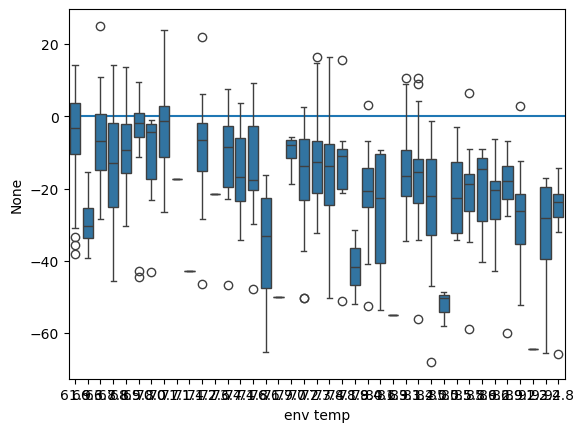

In [289]:
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])

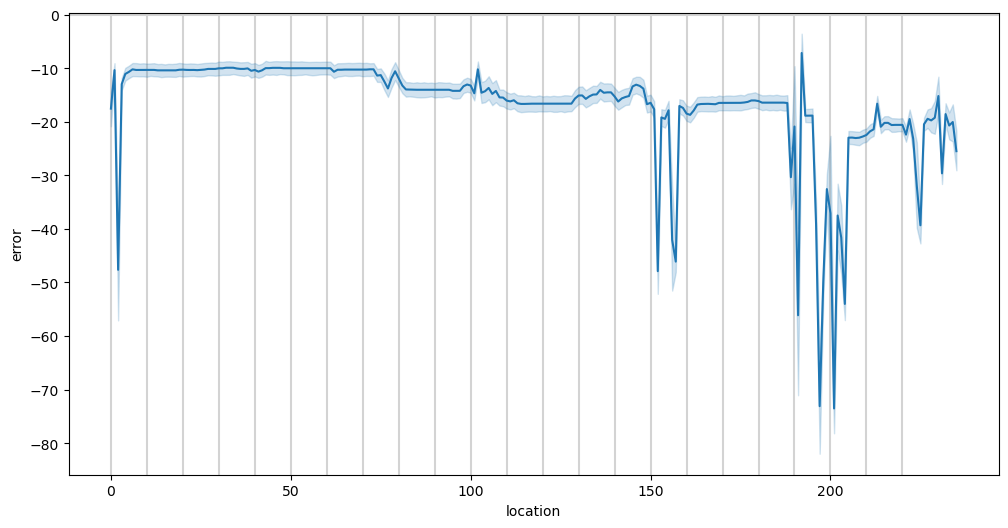

In [290]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [292]:
plotdf.to_csv('./../data/validation_datasets/Colman2024/Coleman2024_error.tsv', sep='\t')

In [293]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
201,-73.521453
197,-73.092892
191,-56.123185
204,-54.008952
198,-49.917977
...,...
45,-9.938117
32,-9.919409
33,-9.919409


In [294]:
counts = colman2024_aln_df.apply(lambda col: col.value_counts(), axis=0).fillna(0)

counts = counts.divide(counts.sum()).T
counts.head()

,-,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,0.814257,0.002008,0.0,0.000000,0.000000,0.000000,0.001004,0.000000,0.002008,0.000000,...,0.135542,0.000000,0.000000,0.000000,0.021084,0.012048,0.001004,0.001004,0.000000,0.001004
1,0.131526,0.003012,0.0,0.002008,0.026104,0.000000,0.008032,0.001004,0.033133,0.029116,...,0.665663,0.000000,0.000000,0.001004,0.017068,0.002008,0.005020,0.052209,0.000000,0.017068
2,0.923695,0.005020,0.0,0.000000,0.000000,0.001004,0.019076,0.000000,0.019076,0.005020,...,0.013052,0.000000,0.000000,0.001004,0.010040,0.001004,0.000000,0.000000,0.001004,0.001004
3,0.128514,0.000000,0.0,0.018072,0.004016,0.004016,0.001004,0.019076,0.112450,0.167671,...,0.005020,0.144578,0.001004,0.003012,0.351406,0.000000,0.000000,0.014056,0.000000,0.019076
4,0.054217,0.003012,0.0,0.000000,0.000000,0.005020,0.000000,0.000000,0.288153,0.001004,...,0.001004,0.000000,0.000000,0.000000,0.014056,0.000000,0.001004,0.130522,0.004016,0.002008


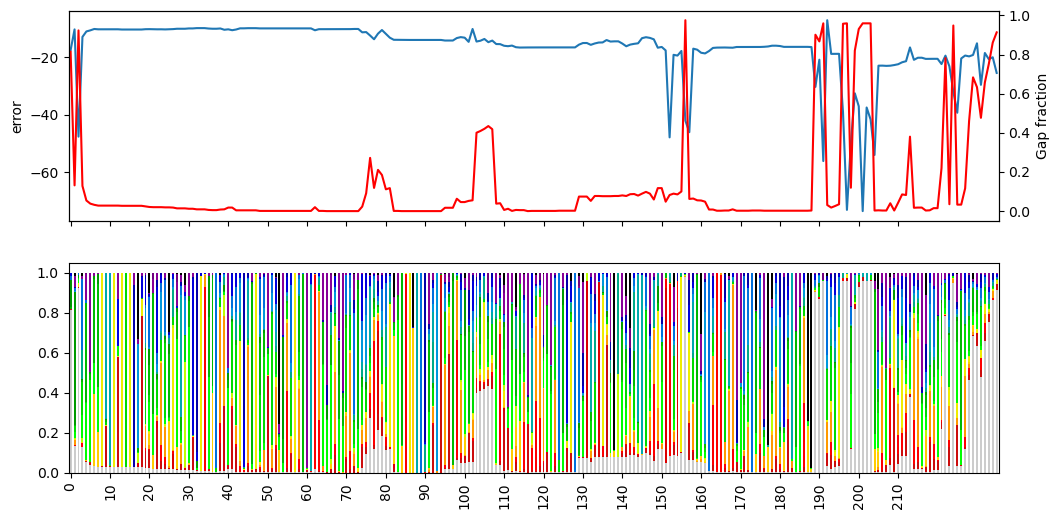

In [295]:
# number of gaps per site
fig= plt.figure(figsize=(12,6))
ax = fig.add_subplot(2,1,1)
sns.lineplot(plotdf.groupby('location').agg({'error':'mean'})['error'], 
             ax=ax)

rax = ax.twinx()
sns.lineplot(colman2024_aln_df.eq('-').sum() / colman2024_aln_df.shape[0], ax=rax, color='r')

rax.set_xlim(10, 210)
rax.set_ylabel('Gap fraction')

ax = fig.add_subplot(2,1,2, sharex=ax)
counts.plot(kind='bar', stacked=True, legend=False, ax=ax, cmap='nipy_spectral_r')
xticks = ax.set_xticks(range(0,220,10))

## Examining embeddings

In [300]:
with open('./../data/validation_datasets/Colman2024/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

colman2024_aln_df = pd.concat(lines, axis=1).T

colman2024_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,226,227,228,229,230,231,232,233,234,235
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [301]:
data = []
for index, row in colman2024_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
    
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [302]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 26min 57s, sys: 26min 21s, total: 53min 18s
Wall time: 4min 56s


In [303]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [304]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

In [305]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [306]:
plotdf.head()

,0,1
GB_GCA_000016765.1,-1.951909,21.641901
GB_GCA_000242235.1,32.616722,32.847656
GB_GCA_000283575.1,3.130796,-10.479993
GB_GCA_000376885.1,-63.828403,-12.298232
GB_GCA_000411155.1,-40.371212,8.162785


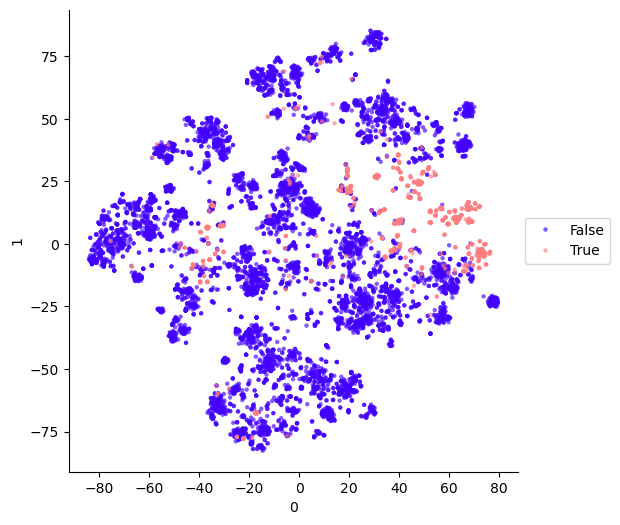

In [307]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('tbl'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


In [309]:
cls_embedding.to_csv('./../data/validation_datasets/Colman2024/Coleman2024_embedding.tsv', sep='\t')

# Royo-Llonch 2021

## 1. Getting metagenomes from ENA

In [310]:
from jsonapi_client import Session
import pandas as pd
import requests

In [311]:
import json

def pp(json_obj):
    print(json.dumps(json_obj, indent=2))


In [314]:
tara_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/41564_2021_979_MOESM4_ESM.xlsx',
             sheet_name='Suppl_Table_13')

In [315]:
results = []
complete = []

In [317]:

for ena_id in list(set(tara_md['ENA_ID'].values) - set(complete)):
    
    print(ena_id)
    # get data for this sample
    sample_url = f"https://www.ebi.ac.uk/metagenomics/api/v1/samples/{ena_id}"
    sample_data = requests.get(sample_url).json()
    if 'errors' in sample_data.keys():
        print('metadata retrieval failed:', ena_id)
        continue 
        
    mg_sample_id = sample_data["data"]["id"]

    # get runs for this sample
    run_data = requests.get(sample_data['data']['relationships']['runs']['links']['related']).json()
    # filter to runs that are metagenomics
    mg_runs = [r for r in run_data['data'] if r['attributes']['experiment-type'] == 'metagenomic']

    # for each run
    for run in mg_runs:
        run_id = run['id']
        try:
            assembly_rel = run['relationships']['assemblies']['data'][0]['links']['self']
        except (IndexError, KeyError):
            print(f'No assembly for run {run_id}')  # no assembly for this run

        assembly_id = assembly_rel.split("/")[-1]
        analyses_url = requests.get(assembly_rel).json()['data']['relationships']['analyses']['links']['related']
        analyses = requests.get(analyses_url).json()['data']

        for analysis in analyses:

            analysis_id = analysis['id']

            # skip non-v5 analyses
            if analysis['attributes']['pipeline-version'] != '5.0':
                # print(f'pipeline 5.0 run found for {analysis_id}')
                continue

            # get download links
            try:
                downloads_url = analysis['relationships']['downloads']['links']['related']
                downloads = requests.get(downloads_url).json()['data']
            except KeyError:
                continue

            for d in downloads:
                label = d['attributes']['description'].get('label', '')
                if label == 'Processed contigs':
                    results.append({
                        "ENA_ID": ena_id,
                        "MGY_Run_ID": run_id,
                        "Assembly_ID": assembly_id,
                        "Pipeline_Job_ID": analysis_id,
                        "Pipeline_v":analysis['attributes']['pipeline-version'],
                        "Download_Link": d['links']['self']
                    })
    
    complete.append(ena_id)
    df = pd.DataFrame(results)
    df.to_csv("~/fiererlab/adenylate_kinase_ogt/data/validation_datasets/temp0_20/RoyoLlonch2021/md/metagenomic_assemblies.tsv", sep='\t', index=False)

In [391]:
with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/temp0_20/RoyoLlonch2021/genomes/download.sh', 'w') as handle:
    handle.write('#!/bin/bash\nwget ')
    handle.write('\nwget '.join(list(df['Download_Link'].unique())))

## 2. Annotating metagenomes

```
ls *.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./
cat ./genomes/*_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

## Step 3. Assemble embeddings

In [80]:
royo2021_aln_df = get_aln_df('./../data/validation_datasets/RoyoLlonch2021/keeplength_adk_nogap.afa')

royo2021_aln_df = royo2021_aln_df[~royo2021_aln_df.index.isin(aln_df.index)]

royo2021_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,224,225,226,227,228,229,230,231,232,233
ERZ7462166.3-NODE-3-length-248082-cov-115.282659_213|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=163.2,M,K,N,L,V,L,F,G,P,P,...,V,I,N,T,L,-,-,-,-,-
ERZ7462166.19-NODE-19-length-118314-cov-159.447188_88|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=167.4,M,I,N,L,V,L,F,G,K,P,...,L,I,V,S,L,-,-,-,-,-
ERZ7462166.38-NODE-38-length-105504-cov-8.016728_31|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.2,M,K,N,I,V,L,F,G,P,P,...,V,F,D,T,L,-,-,-,-,-
ERZ7462166.39-NODE-39-length-105183-cov-15.189436_9|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=182.9,M,-,R,I,I,L,L,G,P,P,...,A,L,A,-,-,-,-,-,-,-
ERZ7462166.42-NODE-42-length-103804-cov-196.745492_96|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.2,M,I,N,L,I,L,F,G,K,P,...,T,I,D,N,N,-,-,-,-,-


In [81]:
data = get_esm_input(royo2021_aln_df)

In [82]:
print(f'There are {len(data)} proteins in this dataset')

There are 8036 proteins in this dataset


In [83]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 29min 35s, sys: 17min 54s, total: 47min 29s
Wall time: 4min 47s


In [86]:
col_datasets = assemble_col_dataset(royo2021_aln_df, labels=labels)

633 rows available for col 233 |##################--|      

## ensemble predictions from main model for environmental species

## metadata parsing

In [97]:
royo2021_chem_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/41564_2021_979_MOESM4_ESM.xlsx',
                           sheet_name = 'Suppl_Table_04')
royo2021_samp_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/41564_2021_979_MOESM4_ESM.xlsx',
                           sheet_name = 'Suppl_Table_13')

<Axes: xlabel='Temperature', ylabel='Count'>

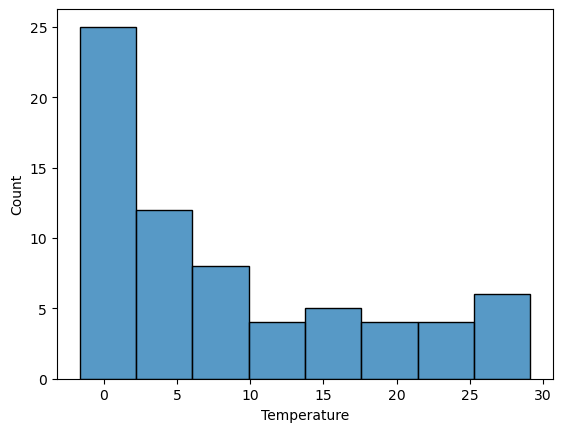

In [98]:
sns.histplot(royo2021_chem_md['Temperature'])

In [99]:
mg_md = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/metagenomic_assemblies.tsv', sep='\t')

In [100]:
merged_md = pd.merge(royo2021_chem_md[['Station.label.num', 'PANGAEA.sample.id', 'Temperature', 'Depth.nominal']], 
         royo2021_samp_md[['PANGAEA sample id', 'ENA_ID', 'MetaG/MetaT']],
        left_on='PANGAEA.sample.id',
        right_on='PANGAEA sample id')

In [101]:
merged_md.head()

,Station.label.num,PANGAEA.sample.id,Temperature,Depth.nominal,PANGAEA sample id,ENA_ID,MetaG/MetaT
0,TARA_025_DCM,TARA_E500000331,15.181967,50,TARA_E500000331,ERS488509,MetaG
1,TARA_025_SRF,TARA_E500000178,18.319192,5,TARA_E500000178,ERS488486,MetaG
2,TARA_032_DCM,TARA_A100001037,26.129250,80,TARA_A100001037,ERS488599,MetaG
3,TARA_032_SRF,TARA_A100001035,25.811708,5,TARA_A100001035,ERS488569,MetaG
4,TARA_041_DCM,TARA_B100000287,27.374181,60,TARA_B100000287,ERS489074,MetaG


In [102]:
merged_md = pd.merge(merged_md, mg_md, left_on='ENA_ID', right_on='ENA_ID')

In [103]:
merged_md.head()

,Station.label.num,PANGAEA.sample.id,Temperature,Depth.nominal,PANGAEA sample id,ENA_ID,MetaG/MetaT,MGY_Run_ID,Assembly_ID,Pipeline_Job_ID,Pipeline_v,Download_Link
0,TARA_025_DCM,TARA_E500000331,15.181967,50,TARA_E500000331,ERS488509,MetaG,ERR599153,ERZ841978,MGYA00590446,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
1,TARA_025_DCM,TARA_E500000331,15.181967,50,TARA_E500000331,ERS488509,MetaG,ERR599094,ERZ841404,MGYA00590499,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
2,TARA_025_SRF,TARA_E500000178,18.319192,5,TARA_E500000178,ERS488486,MetaG,ERR599043,ERZ840593,MGYA00590542,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
3,TARA_025_SRF,TARA_E500000178,18.319192,5,TARA_E500000178,ERS488486,MetaG,ERR598951,ERZ829891,MGYA00593132,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
4,TARA_032_DCM,TARA_A100001037,26.129250,80,TARA_A100001037,ERS488599,MetaG,ERR599097,ERZ841426,MGYA00590493,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...


In [104]:
# check all Assemblies have 1 unique temperature
print('Assemblies w/ multiple temps (not good):', (merged_md.groupby('Assembly_ID').apply(lambda x: len(x['Temperature'].unique())) != 1).sum())



Assemblies w/ multiple temps (not good): 0


In [105]:
assembly2temp = merged_md.groupby('Assembly_ID').first()['Temperature']

In [117]:
y = pd.Series(index=royo2021_aln_df.index, data=[s for s in royo2021_aln_df.index], name='env temp')

In [118]:
y = y.reset_index().rename(columns={'index':'protein'})
y['sample_or_genome'] = y['protein'].apply(lambda x: x.split('|')[1].split('_FASTA')[0])
y['env temp'] = y['sample_or_genome'].map(assembly2temp)
y

,protein,env temp,sample_or_genome
0,ERZ7462166.3-NODE-3-length-248082-cov-115.2826...,-1.649738,ERZ7462166
1,ERZ7462166.19-NODE-19-length-118314-cov-159.44...,-1.649738,ERZ7462166
2,ERZ7462166.38-NODE-38-length-105504-cov-8.0167...,-1.649738,ERZ7462166
3,ERZ7462166.39-NODE-39-length-105183-cov-15.189...,-1.649738,ERZ7462166
4,ERZ7462166.42-NODE-42-length-103804-cov-196.74...,-1.649738,ERZ7462166
...,...,...,...
8031,ERZ842953.1092676-NODE-2109637-length-664-cov-...,19.783275,ERZ842953
8032,ERZ842953.1096368-NODE-2116667-length-1090-cov...,19.783275,ERZ842953
8033,ERZ842953.1097691-NODE-2119186-length-3244-cov...,19.783275,ERZ842953
8034,ERZ842953.1098190-NODE-2120116-length-1339-cov...,19.783275,ERZ842953


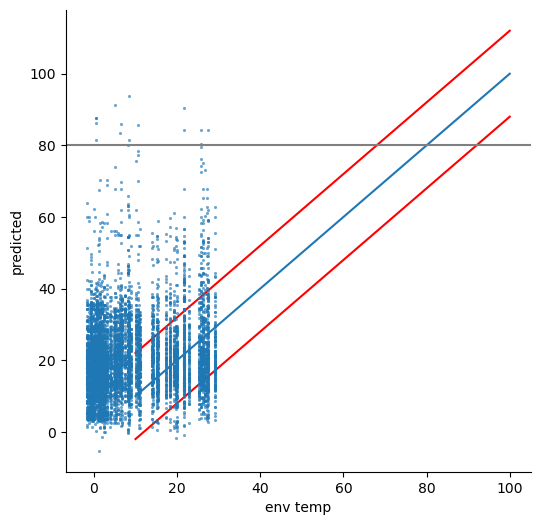

In [119]:
plotdf = plot_predictions(col_datasets, y)

# ax.set_title('Mycobacteria')

In [120]:
plotdf

,predicted,protein,env temp,sample_or_genome
0,15.072682,ERZ7462166.3-NODE-3-length-248082-cov-115.2826...,-1.649738,ERZ7462166
1,19.300283,ERZ7462166.19-NODE-19-length-118314-cov-159.44...,-1.649738,ERZ7462166
2,18.168995,ERZ7462166.38-NODE-38-length-105504-cov-8.0167...,-1.649738,ERZ7462166
3,12.781556,ERZ7462166.39-NODE-39-length-105183-cov-15.189...,-1.649738,ERZ7462166
4,24.258118,ERZ7462166.42-NODE-42-length-103804-cov-196.74...,-1.649738,ERZ7462166
...,...,...,...,...
7683,21.966360,ERZ842130.5954-NODE-5954-length-4640-cov-25.02...,8.149894,ERZ842130
7696,22.672642,ERZ842130.32746-NODE-32746-length-1617-cov-1.3...,8.149894,ERZ842130
7708,39.517166,ERZ842130.218079-NODE-218080-length-563-cov-1....,8.149894,ERZ842130
7734,24.778740,ERZ842135.65781-NODE-65781-length-683-cov-2.37...,0.731590,ERZ842135


In [121]:
plotdf.to_csv('./../data/validation_datasets/RoyoLlonch2021/RoyoLlonch2021_predictions.tsv', sep='\t')

## Errors

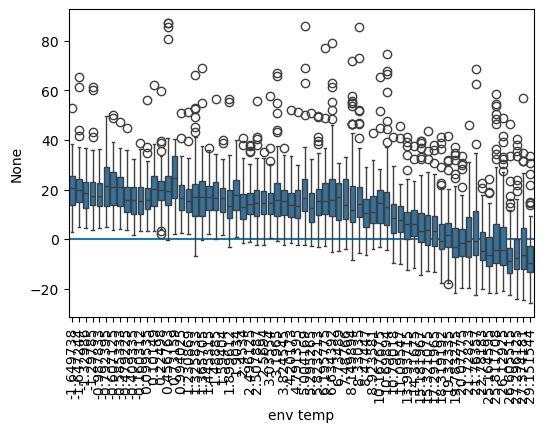

In [340]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

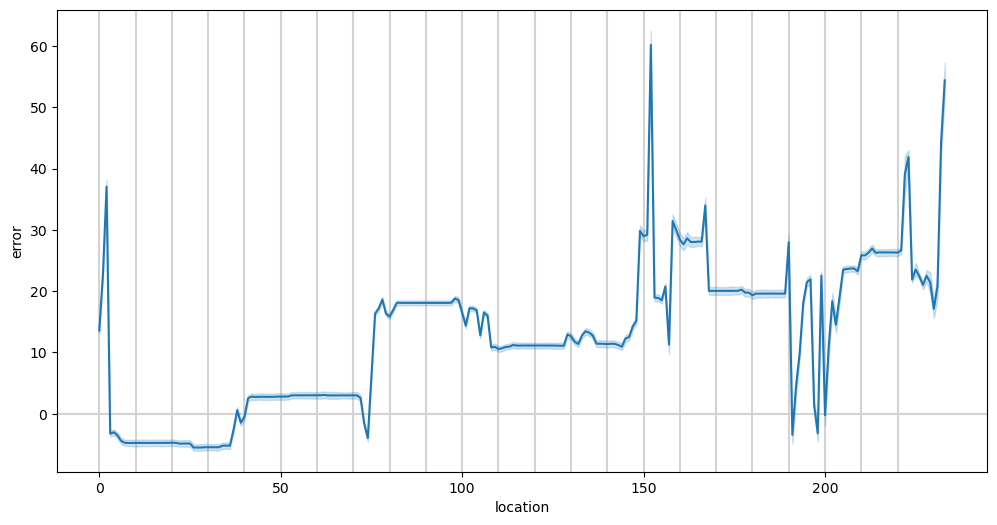

In [341]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [342]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
26,-5.515041
28,-5.513565
27,-5.513565
31,-5.468725
30,-5.468725
...,...
222,39.074986
223,41.888603
232,44.359085


In [343]:
plotdf.to_csv('./../data/validation_datasets/RoyoLlonch2021/RoyoLlonch2021_errors.tsv', sep='\t')

In [344]:
counts = royo2021_aln_df.apply(lambda col: col.value_counts(), axis=0).fillna(0)

counts = counts.divide(counts.sum()).T
counts.head()

,-,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,0.239547,0.003360,0.000000,0.000622,0.000000,0.000249,0.000871,0.003858,0.003858,0.010329,...,0.718766,0.000747,0.000498,0.000000,0.007964,0.001618,0.003235,0.002613,0.000000,0.000124
1,0.797287,0.000373,0.000373,0.000000,0.000124,0.005849,0.000124,0.000000,0.044052,0.037083,...,0.012320,0.000000,0.001369,0.000124,0.006844,0.000249,0.015431,0.001618,0.000747,0.000373
2,0.214659,0.000000,0.000000,0.003609,0.000249,0.000498,0.004978,0.017048,0.016924,0.126307,...,0.036959,0.339223,0.000249,0.017546,0.191762,0.000747,0.004231,0.003360,0.001244,0.004604
3,0.037705,0.004231,0.000000,0.000000,0.000000,0.009706,0.000000,0.000000,0.544674,0.000747,...,0.016426,0.003609,0.000000,0.000000,0.000000,0.000373,0.008835,0.092583,0.000124,0.000498
4,0.035341,0.001369,0.000124,0.000000,0.000000,0.003858,0.000000,0.000000,0.613863,0.000000,...,0.005973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.273519,0.000000,0.000124


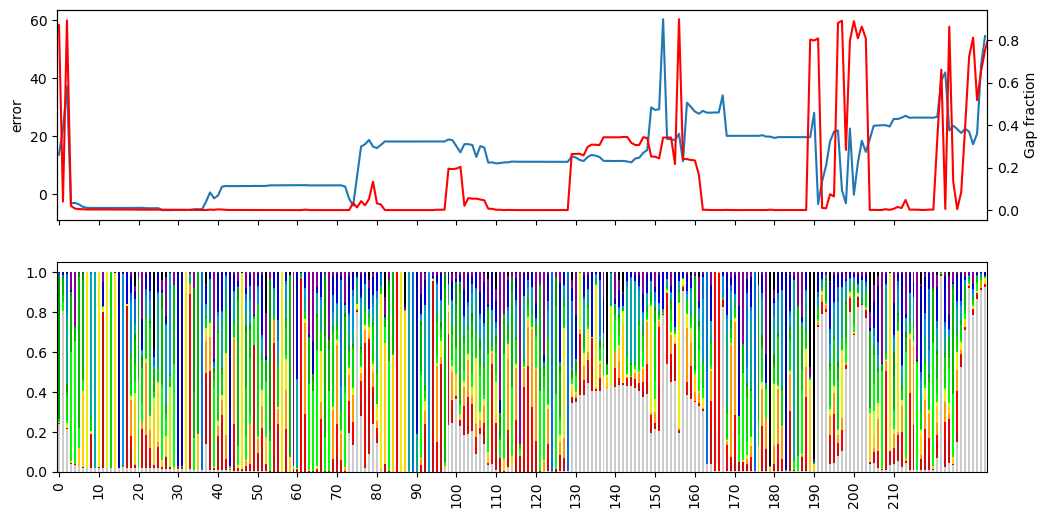

In [345]:
# number of gaps per site
fig= plt.figure(figsize=(12,6))
ax = fig.add_subplot(2,1,1)
sns.lineplot(plotdf.groupby('location').agg({'error':'mean'})['error'], 
             ax=ax)

rax = ax.twinx()
sns.lineplot(colman2024_aln_df.eq('-').sum() / colman2024_aln_df.shape[0], ax=rax, color='r')

rax.set_xlim(10, 210)
rax.set_ylabel('Gap fraction')

ax = fig.add_subplot(2,1,2, sharex=ax)
counts.plot(kind='bar', stacked=True, legend=False, ax=ax, cmap='nipy_spectral_r')
xticks = ax.set_xticks(range(0,220,10))

## Examining embeddings

In [346]:
with open('./../data/validation_datasets/RoyoLlonch2021/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

royo2021_aln_df = pd.concat(lines, axis=1).T

royo2021_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,224,225,226,227,228,229,230,231,232,233
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,M,-,N,I,I,L,L,G,P,P,...,I,L,D,N,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,-,G,I,V,M,L,G,A,P,...,A,L,L,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,M,-,R,L,I,L,L,G,A,P,...,A,L,G,-,-,-,R,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,M,-,R,L,L,I,M,G,P,Q,...,E,L,T,K,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,-,-,A,I,L,I,L,G,A,P,...,V,L,E,Y,-,L,L,E,K,-


In [347]:
data = []
for index, row in royo2021_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
    
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [348]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 42min 48s, sys: 44min 17s, total: 1h 27min 6s
Wall time: 8min 25s


In [349]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [350]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

In [351]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [352]:
plotdf.head()

,0,1
GB_GCA_000016765.1,-4.304157,-47.253349
GB_GCA_000242235.1,20.049311,-24.422789
GB_GCA_000283575.1,-19.949972,-17.150942
GB_GCA_000376885.1,-57.305477,-42.256126
GB_GCA_000411155.1,54.273739,-73.965363


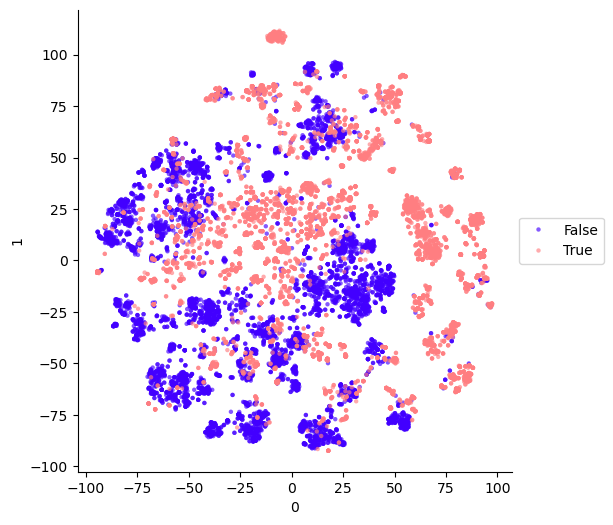

In [353]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('tbl'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


In [354]:
cls_embedding.to_csv('./../data/validation_datasets/RoyoLlonch2021/RoyoLlonch2021_embedding.tsv', sep='\t')

# Shah 2024
Metagenomes: `https://www.ncbi.nlm.nih.gov/bioproject/PRJNA1052970`
Download SRA run table
`cut -f 1 -d, Shah2024_SraRunTable.csv > accessions.txt`  
`~/tools/sratoolkit.2.11.3-centos_linux64/bin/prefetch --option-file ./../md/accessions.txt --max-size 100Gb`



## Parse metadata

In [122]:
shah_md = pd.read_excel('./../data/validation_datasets/Shah2024/md/emi16634-sup-0002-tables1.xlsx', )

In [123]:
shah_md.head()

,ID,name,SRA_AccessionID,date,country,region,time,elevation,pH1,conductivity,...,TP,DP,DOC,DN,DRSi,elevation_level,pH_level,conductivity_level,temperature_level,nutrient_level
0,EULd_A251SC,Schwarzsee,SAMN38848240,41146,Austria,Kitzbüheler Alpen,12:15:00,2785,6.85,25,...,1.8,1.2,1381,88.0,1069,High_Elevation,Low_pH,Low_conductivity,Low_temp,Low_nutrient
1,EULd_S102LR,Laguna de las Aguas Verdes,SAMN38848241,41131,Spain,Sierra Nevada,00:00:00,3110,8.42,42,...,6.2,5.0,1627,58.0,822,High_Elevation,Low_pH,Low_conductivity,Low_temp,Low_nutrient
2,EULd_S191UT,Embalse de Utxesa,SAMN38848242,41140,Spain,Pyrenäen,11:00:00,207,8.29,680,...,40.9,9.7,2510,2743.0,3246,Low_Elevation,Low_pH,High_conductivity,High_temp,High_nutrient
3,EULd_S201PO,Embalse de Pondiellas,SAMN38848243,41141,Spain,Pyrenäen,14:55:00,2805,8.74,82,...,1.7,1.4,686,200.0,436,High_Elevation,High_pH,Low_conductivity,Low_temp,Low_nutrient
4,EULd_S271TO,Lac du Tordre,SAMN38848244,41148,France,nördlich von Toulouse,09:10:00,175,8.76,351,...,23.5,9.3,6175,494.0,613,Low_Elevation,High_pH,High_conductivity,High_temp,High_nutrient


In [124]:
shah_sra = pd.read_csv('./../data/validation_datasets/Shah2024/md/Shah2024_SraRunTable.csv')
shah_full_md = pd.merge(shah_sra[['Run', 'Sample Name']], shah_md, 
        right_on='ID',
        left_on='Sample Name')

## Assembling embedding

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
cat ./genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [146]:
shah2024_aln_df = get_aln_df('./../data/validation_datasets/Shah2024/keeplength_adk_nogap.afa') 

shah2024_aln_df = shah2024_aln_df[~shah2024_aln_df.index.isin(aln_df.index)]

shah2024_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
NODE_31_length_45646_cov_14.254173_22|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=186.3,-,M,-,R,I,I,L,L,G,P,...,L,G,G,-,-,-,-,-,-,-
NODE_78_length_34106_cov_45.718599_14|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=173.8,-,M,-,K,L,L,F,L,G,P,...,L,G,-,-,-,-,-,-,-,-
NODE_131_length_26054_cov_21.223739_23|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.5,-,-,-,-,-,-,M,L,G,P,...,L,G,-,-,-,R,-,-,-,-
NODE_305_length_16248_cov_7.298154_22|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.8,-,M,-,R,L,I,L,I,G,P,...,V,R,A,R,S,R,R,R,-,-
NODE_437_length_13545_cov_7.006004_7|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.0,-,M,-,Q,L,L,F,L,G,P,...,L,G,-,-,-,-,-,-,-,-


In [147]:
data = get_esm_input(shah2024_aln_df)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [148]:
print(f'There are {len(data)} proteins in this dataset')

There are 1175 proteins in this dataset


In [149]:
shah2024_aln_df.shape

(1191, 237)

In [150]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 4min 8s, sys: 2min 51s, total: 6min 59s
Wall time: 45.2 s


In [151]:
len(labels)

1175

In [153]:
col_datasets = assemble_col_dataset(shah2024_aln_df.reindex(index=labels), labels)

58 rows available for col 236 |--------------------|       

In [154]:
# make mapping of sequence ID to sample ID
shah2024_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Shah2024/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            shah2024_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [170]:
y =  pd.merge(pd.Series(shah2024_record2sample).reset_index(), 
              shah_full_md[['Run', 'temperature']],
             left_on=0, right_on='Run').rename(columns={'temperature':'env temp', 
                                                        'Run':'sample_or_genome', 'index':'protein'}).drop(0, axis=1)


In [171]:
y

,protein,sample_or_genome,env temp
0,NODE_92_length_20263_cov_9.424980_1|scaffolds_...,SRR27216432,24.3
1,NODE_211_length_13243_cov_11.405899_7|scaffold...,SRR27216432,24.3
2,NODE_839_length_6394_cov_8.444550_11|scaffolds...,SRR27216432,24.3
3,NODE_887_length_6232_cov_6.602720_6|scaffolds_...,SRR27216432,24.3
4,NODE_1309_length_5105_cov_28.407723_8|scaffold...,SRR27216432,24.3
...,...,...,...
1186,NODE_40321_length_1061_cov_3.578529_2|scaffold...,SRR27216462,20.2
1187,NODE_44191_length_1002_cov_4.407603_2|scaffold...,SRR27216462,20.2
1188,NODE_64754_length_787_cov_2.945355_1|scaffolds...,SRR27216462,20.2
1189,NODE_87719_length_647_cov_3.927365_1|scaffolds...,SRR27216462,20.2


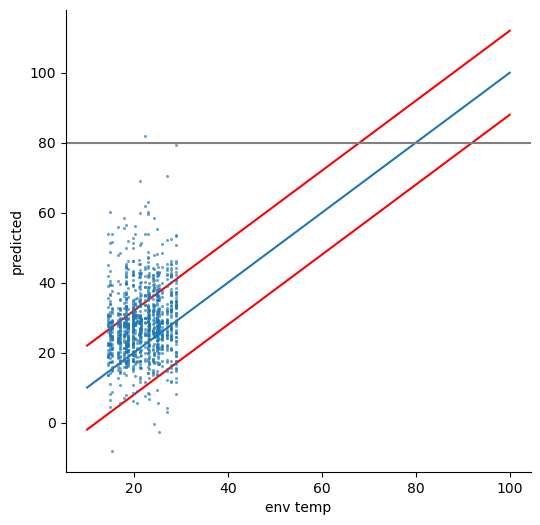

In [172]:
plotdf = plot_predictions(col_datasets, y)

In [173]:
plotdf

,predicted,protein,sample_or_genome,env temp
0,24.340096,NODE_92_length_20263_cov_9.424980_1|scaffolds_...,SRR27216432,24.3
5,38.678699,NODE_1618_length_4624_cov_27.221493_3|scaffold...,SRR27216432,24.3
14,24.408705,NODE_10555_length_1849_cov_2.912486_1|scaffold...,SRR27216432,24.3
16,17.051756,NODE_19186_length_1385_cov_2.821805_2|scaffold...,SRR27216432,24.3
74,44.280491,NODE_4160_length_5165_cov_6.552055_3|scaffolds...,SRR27216455,23.0
...,...,...,...,...
1189,33.866051,NODE_87719_length_647_cov_3.927365_1|scaffolds...,SRR27216462,20.2
1190,27.997747,NODE_165052_length_433_cov_2.904762_1|scaffold...,SRR27216462,20.2
738,19.045485,NODE_56086_length_1169_cov_2.456014_2|scaffold...,SRR27216441,23.1
733,27.884771,NODE_47561_length_1293_cov_2.459612_1|scaffold...,SRR27216441,23.1


In [174]:
plotdf.to_csv('./../data/validation_datasets/Shah2024/Shah2024_predictions.tsv', sep='\t')

## Errors

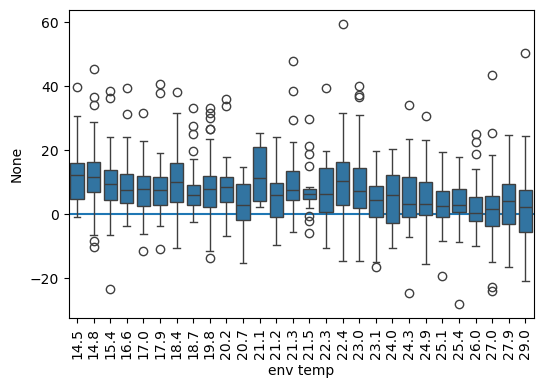

In [419]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

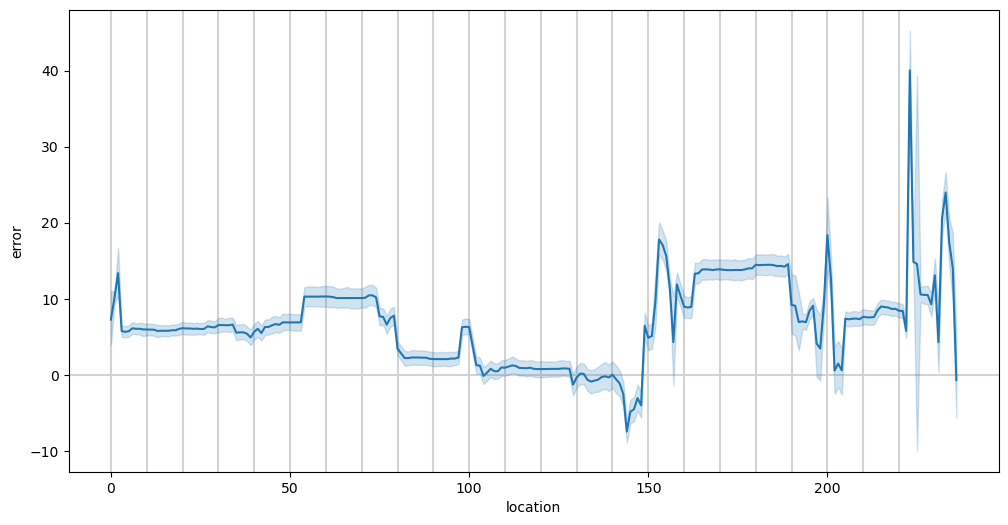

In [420]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [421]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
144,-7.448006
145,-4.833661
146,-4.526620
148,-4.016139
147,-3.055262
...,...
153,17.801854
200,18.366343
232,20.600063


In [422]:
plotdf.to_csv('./../data/validation_datasets/Shah2024/Shah2024_errors.tsv', sep='\t')

In [424]:
data = []
for index, row in shah2024_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
    
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [425]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 5min 4s, sys: 3min 12s, total: 8min 16s
Wall time: 38.6 s


In [426]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [427]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

In [428]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [429]:
plotdf.head()

,0,1
scaffolds_hmmsearch.tbl,-2.864906,-17.039801
scaffolds_hmmsearch.tbl,-36.965279,-14.701384
scaffolds_hmmsearch.tbl,29.622263,8.788299
scaffolds_hmmsearch.tbl,-23.567587,-15.435713
scaffolds_hmmsearch.tbl,-37.841209,-16.255636


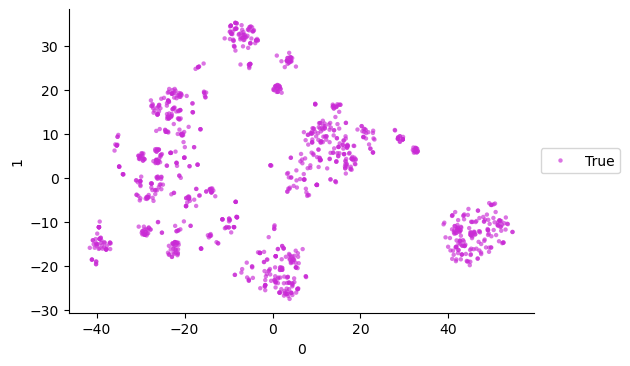

In [430]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('tbl'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


In [431]:
cls_embedding.to_csv('./../data/validation_datasets/Shah2024/Shah2024_embedding.tsv', sep='\t')

# Australia

In [214]:
with open('./../base_api_key.txt', 'r') as handle:
    api_key = handle.read()

In [215]:
import ckanapi
remote = ckanapi.RemoteCKAN('https://data.bioplatforms.com', apikey=api_key)
# we increase the number of rows to be returned, and we
# ask for all packages, including private packages
result = remote.action.package_search(
    q='type:base-metagenomics',
    rows=50000,
    include_private=True)
print("{} matches found.".format(result['count']))

447 matches found.


In [28]:
[r['sample_extraction_id'] for r in result['results']]

['9588_1',
 '9586_1',
 '9576_1',
 '9573_1',
 '9571_1',
 '9569_1',
 '9567_1',
 '9530_1',
 '9528_2',
 '9526_2',
 '9524_1',
 '9522_1',
 '9514_1',
 '9512_1',
 '9510_1',
 '9508_1',
 '9506_1',
 '9504_1',
 '9502_1',
 '9500_1',
 '9498_1',
 '9496_1',
 '9494_1',
 '9492_1',
 '9490_1',
 '9488_1',
 '9486_1',
 '9484_1',
 '9468_1',
 '9466_1',
 '9466_1',
 '9464_1',
 '9462_1',
 '9460_1',
 '9458_1',
 '9456_1',
 '9454_1',
 '9452_1',
 '9450_1',
 '9450_1',
 '9448_1',
 '9446_1',
 '9444_1',
 '9442_1',
 '9440_1',
 '9438_1',
 '9436_1',
 '9434_1',
 '9432_1',
 '9430_1',
 '8531_1',
 '8531_1',
 '8529_1',
 '8527_1',
 '8527_1',
 '8525_1',
 '8523_1',
 '8523_1',
 '8521_1',
 '8519_1',
 '8517_1',
 '8515_1',
 '8513_1',
 '8511_1',
 '8509_1',
 '8507_1',
 '8497_1',
 '8497_1',
 '8495_1',
 '8493_1',
 '8491_1',
 '8489_1',
 '8487_1',
 '8461_1',
 '8461_1',
 '8459_2',
 '8457_2',
 '8455_2',
 '8271_2',
 '8271_2',
 '8270_2',
 '8269_2',
 '8269_2',
 '8268_2',
 '8268_2',
 '8263_2',
 '8263_2',
 '8262_2',
 '8262_2',
 '8164_1',
 '8164_1',

## perform predictions

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [175]:
aus_aln_df = get_aln_df('./../data/validation_datasets/Australia/keeplength_adk_nogap.afa')

aus_aln_df = aus_aln_df[~aus_aln_df.index.isin(aln_df.index)]

aus_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
NODE_3158_length_2801_cov_1.389658_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=102.3,-,M,-,N,L,I,L,L,G,P,...,L,A,A,-,A,S,G,G,G,T
NODE_3427_length_2716_cov_4.868846_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=180.5,-,M,-,R,V,V,L,L,G,P,...,L,-,E,A,R,R,P,D,G,P
NODE_6928_length_2034_cov_2.804952_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=129.4,-,M,-,K,V,S,L,L,G,P,...,L,G,N,-,-,R,V,-,-,-
NODE_9829_length_1740_cov_1.804748_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=119.1,-,M,L,R,V,L,L,L,G,P,...,L,A,S,-,-,R,T,V,S,G
NODE_15715_length_1400_cov_1.133829_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=124.1,-,-,-,-,-,-,M,L,A,P,...,L,R,-,-,-,-,-,-,-,-


In [176]:
data = get_esm_input(aus_aln_df)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [177]:
print(f'There are {len(data)} proteins in this dataset')

There are 719 proteins in this dataset


In [178]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 2min 42s, sys: 1min 40s, total: 4min 23s
Wall time: 27.7 s


In [179]:
len(labels)

719

In [182]:
col_datasets = assemble_col_dataset(aus_aln_df.reindex(index=labels), labels)

200 rows available for col 236 |##########----------|     

In [183]:
# make mapping of sequence ID to sample ID
aus_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Australia/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            aus_record2sample[r.id] = t.split("/")[-2].replace('_spades', '').split('_')[0]

## parse metadata

In [184]:
aus_md = pd.read_csv('./../data/validation_datasets/Australia/md/metadata_331.txt', sep='\t')
aus_md['Sample'] = aus_md['Sample'].apply(lambda x: x.lstrip('X'))

In [185]:
aus_md['bio1']

0      17.55267
1      17.58800
2      17.61733
3      17.46267
4      12.64583
         ...   
326     7.36600
327     7.28467
328     6.69100
329     9.63867
330     9.63867
Name: bio1, Length: 331, dtype: float64

In [186]:
y =  pd.merge(pd.Series(aus_record2sample).reset_index(), 
              aus_md[['Sample', 'bio1']],
             left_on=0, right_on='Sample').rename(columns={'bio1':'env temp', 
                                                        'Sample':'sample_or_genome', 'index':'protein'}).drop(0, axis=1)

y

,protein,sample_or_genome,env temp
0,NODE_3158_length_2801_cov_1.389658_2|scaffolds...,10714,17.55267
1,NODE_3427_length_2716_cov_4.868846_2|scaffolds...,10714,17.55267
2,NODE_6928_length_2034_cov_2.804952_1|scaffolds...,10714,17.55267
3,NODE_9829_length_1740_cov_1.804748_1|scaffolds...,10714,17.55267
4,NODE_15715_length_1400_cov_1.133829_2|scaffold...,10714,17.55267
...,...,...,...
763,NODE_41327_length_962_cov_3.771775_2|scaffolds...,138526,13.18646
764,NODE_52409_length_871_cov_2.493873_2|scaffolds...,138526,13.18646
765,NODE_76034_length_749_cov_1.612392_1|scaffolds...,138526,13.18646
766,NODE_98262_length_675_cov_1.638710_1|scaffolds...,138526,13.18646


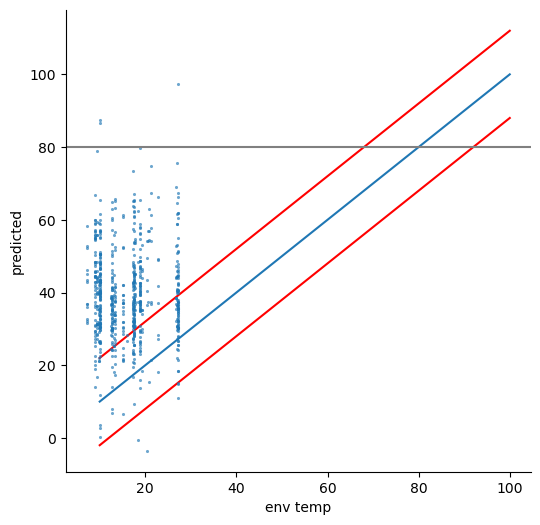

In [187]:
plotdf = plot_predictions(col_datasets, y)

# ax.set_title('Mycobacteria')

In [188]:
plotdf #sns.histplot(aus_md['bio1'])

,predicted,protein,sample_or_genome,env temp
5,36.388107,NODE_15752_length_1398_cov_1.498883_1|scaffold...,10714,17.55267
12,37.848774,NODE_539_length_13686_cov_3.625119_8|scaffolds...,10716,17.58800
88,33.085964,NODE_6885_length_2446_cov_1.822668_2|scaffolds...,12426,12.64583
138,44.052586,NODE_2266_length_3487_cov_2.283217_7|scaffolds...,12447,9.37217
142,39.492771,NODE_49430_length_896_cov_2.055886_1|scaffolds...,12447,9.37217
...,...,...,...,...
730,36.984722,NODE_51732_length_1038_cov_8.246185_1|scaffold...,138515,15.08633
765,32.235214,NODE_76034_length_749_cov_1.612392_1|scaffolds...,138526,13.18646
767,40.759937,NODE_142850_length_580_cov_1.638095_1|scaffold...,138526,13.18646
459,75.482307,NODE_40958_length_912_cov_1.346558_1|scaffolds...,12878,26.87500


In [189]:
plotdf.to_csv('./../data/validation_datasets/Australia/Australia_predictions.tsv', sep='\t')

## Errors

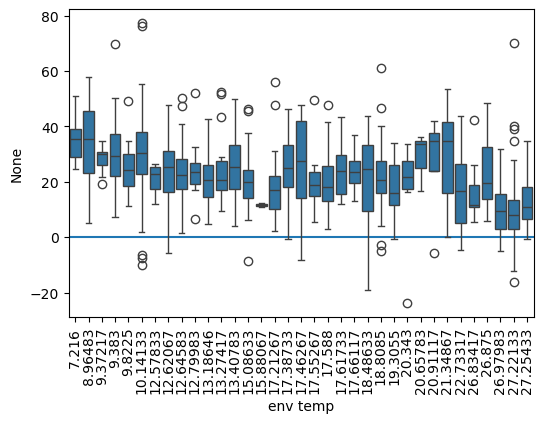

In [451]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

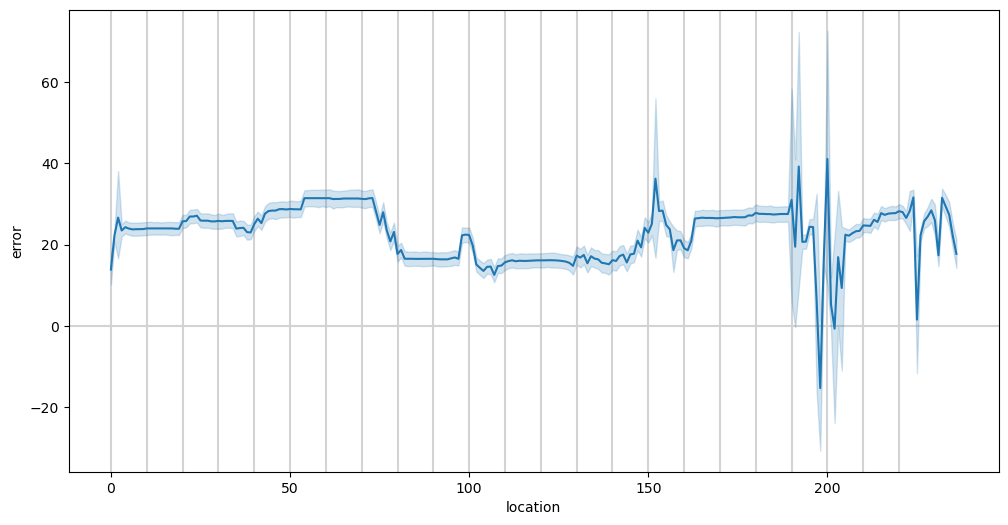

In [452]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [453]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
198,-15.290060
202,-0.674239
225,1.553827
201,5.291944
197,6.191741
...,...
232,31.515828
224,31.617669
152,36.216118


In [454]:
plotdf.to_csv('./../data/validation_datasets/Australia/Australia_errors.tsv', sep='\t')

# Antarctica

In [459]:
ant_md = pd.read_excel('./../data/validation_datasets/Antarctic/md/Dataset_S1_Metadata.xlsx', header=1)
ant_md

,Sample_ID,abbr_id,sample_location,location_group,LAT,LON,Elevation (m.a.s.l.),Distance from coast (km),pH_MQ,pH_KCl,...,Tl1908,V_2924,Zn2138,δ15NAIR (‰),δ13CVPDB (‰),Wt% N,Wt% C,C/N,Mean Annual Temp (oC),Annual Precipitation (mm/year)
0,AV1_1,AV,Shackleton Glacier,Shackleton Glacier,-85.176217,-174.088483,1471.07,71.2,6.628,5.766,...,2.0,31.12,35.74,-15.493,-34.477,0.144,0.012,0.086,-29.75,241.6
1,AV1_8,AV,Shackleton Glacier,Shackleton Glacier,-85.175950,-174.116533,1417.26,71.1,7.026,6.234,...,2.0,52.10,41.42,-7.376,-32.796,0.148,0.023,0.159,-29.95,243.0
2,AV2_1,AV,Shackleton Glacier,Shackleton Glacier,-85.170600,-174.133800,1404.25,70.5,7.791,7.198,...,2.0,46.62,38.17,-12.877,-25.955,0.030,0.034,1.134,-29.25,234.2
3,AV3_1,AV,Shackleton Glacier,Shackleton Glacier,-85.170683,-174.148300,1429.82,70.4,7.186,6.322,...,2.0,47.90,36.83,-17.971,-29.747,0.048,0.032,0.675,-29.25,234.4
4,AV3_7,AV,Shackleton Glacier,Shackleton Glacier,-85.167083,-174.150833,1367.45,70.1,6.776,5.233,...,2.0,25.15,49.00,0.588,-24.864,0.018,0.060,3.269,-29.35,234.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,WV_BA_1,WV,Wall Valley: Recon,Wall Valley,-77.495560,160.875170,1734.92,62.5,7.462,5.775,...,2.0,13.76,4.52,-9.947,-32.149,0.008,0.035,4.599,-30.45,114.1
196,WV_UNN1,WV,Wall Valley: Recon,Wall Valley,-77.480000,160.850000,1474.63,61.4,7.846,5.874,...,2.0,24.30,21.90,-8.628,-32.378,0.009,0.034,3.825,-30.95,104.1
197,WV_UNN3,WV,Wall Valley: Recon,Wall Valley,-77.480000,160.850000,1474.63,61.4,7.582,5.646,...,2.0,17.87,11.24,-11.027,-29.712,0.008,0.035,4.590,-30.95,104.1
198,WV_UNN_2,WV,Wall Valley: Recon,Wall Valley,-77.480000,160.850000,1474.63,61.4,7.672,5.841,...,2.0,25.60,18.15,-11.060,-31.543,0.008,0.032,4.098,-30.95,104.1


## perform predictions

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [190]:
ant_aln_df = get_aln_df('./../data/validation_datasets/Antarctic/keeplength_adk_nogap.afa')

ant_aln_df = ant_aln_df[~ant_aln_df.index.isin(aln_df.index)]

ant_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
NODE_10_length_78737_cov_17.419680_76|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.4,-,M,-,D,L,I,L,L,G,A,...,L,D,H,-,-,-,-,-,-,-
NODE_20_length_67352_cov_11.772813_23|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=141.5,-,-,-,H,V,I,L,M,G,A,...,V,S,L,-,-,R,R,L,A,Q
NODE_85_length_44008_cov_45.300289_31|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=131.7,-,-,T,R,L,I,V,L,G,R,...,V,G,T,R,D,C,A,P,P,P
NODE_120_length_38874_cov_5.104235_16|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.4,-,M,-,N,L,I,L,L,G,A,...,L,G,R,-,-,-,-,-,-,-
NODE_234_length_29482_cov_13.620507_10|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=166.6,-,-,-,-,-,-,M,F,G,P,...,L,G,-,-,-,E,R,A,-,S


In [191]:
data = get_esm_input(ant_aln_df)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [192]:
print(f'There are {len(data)} proteins in this dataset')

There are 978 proteins in this dataset


In [193]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 3min 37s, sys: 2min 15s, total: 5min 53s
Wall time: 37.5 s


In [194]:
len(labels)

978

In [196]:
col_datasets = assemble_col_dataset(ant_aln_df.reindex(index=labels), labels)

268 rows available for col 236 |##############------|     

In [197]:
# make mapping of sequence ID to sample ID
ant_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Antarctic/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            ant_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [198]:
ant_record2sample

{'NODE_16_length_92306_cov_8.605710_14|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.2': 'BS610',
 'NODE_52_length_46706_cov_18.276008_3|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.4': 'BS610',
 'NODE_56_length_45654_cov_8.929394_45|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=148.0': 'BS610',
 'NODE_61_length_43867_cov_10.707741_40|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=170.9': 'BS610',
 'NODE_128_length_27827_cov_4.801045_23|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=162.4': 'BS610',
 'NODE_436_length_15166_cov_4.758698_17|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=165.7': 'BS610',
 'NODE_583_length_12578_cov_4.511799_8|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=135.8': 'BS610',
 'NODE_809_length_10819_cov_3.753770_15|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=180.9': 'BS610',
 'NODE_943_length_9991_cov_3.881682_16|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=152.8': 'BS610',
 'NODE_1290_length_8419_cov_2.555382_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=162

## parse metadata

In [199]:
ant_md = pd.read_excel('./../data/validation_datasets/Antarctic/md/Dataset_S1_Metadata.xlsx', header=1)
ant_md['Sample_ID'] = ant_md['Sample_ID'].apply(lambda x: x.replace('_', '').replace('-', ''))
ant_md['Sample_ID'].unique()

array(['AV11', 'AV18', 'AV21', 'AV31', 'AV37', 'BP11', 'BP18', 'BP21',
       'BP31', 'BP38', 'BPS1', 'BPS18', 'BPS22', 'BPS25', 'BPS5', 'BS607',
       'BS610', 'BS618', 'BS620', 'CBCMBjA1', 'CBiH5', 'CK20B', 'CK1100B',
       'CK210', 'CK2100A', 'CK2100B', 'CM21', 'CM4', 'CMPA310', 'CMPA30',
       'CM20M', 'CR0819', 'CR0821', 'CR0826', 'CR0828', 'CR0833',
       'CSCR11', 'CSCR2', 'CSCR5', 'CSCR7', 'CSCR9', 'DA1', 'DA3', 'DA4',
       'DA5', 'DA6', 'DS112', 'DS212', 'GEA13', 'GEA22', 'GEB13', 'GEC23',
       'GEC32', 'HCBA1', 'HCBA2', 'HCZ51', 'HCZS2', 'HD10', 'HD11',
       'HD14', 'HD6', 'HD9', 'HG3', 'HG54', 'HG6', 'HG8', 'HG9', 'HH1',
       'HH2', 'HH3', 'HK1', 'HK2', 'HK3', 'HK4', 'HK5', 'HM2', 'HM3',
       'HM5', 'HM6', 'HR1', 'HR2', 'HR3', 'HR4', 'HR5', 'HS1', 'HS2',
       'HS3', 'HS4', 'HS7', 'HV18', 'HV25', 'HV31', 'HV39', 'HVY4A',
       'HVY5A', 'HVY9054A', 'HVY9062A', 'HVY9130A', 'KR1', 'KR2', 'KR4',
       'LC15', 'LC35', 'LC41', 'LGP34', 'LGPBA13', 'LGPBALV8', 'LSI1

In [200]:
ant_md.columns

Index(['Sample_ID', 'abbr_id', 'sample_location', 'location_group', 'LAT',
       'LON', 'Elevation (m.a.s.l.)', 'Distance from coast (km)', 'pH_MQ',
       'pH_KCl', 'pH_CaCl2', 'EC (uS/cm)', 'CEC (meq/100 g)', 'F-', 'Cl-',
       'NO3-', 'PO43-', 'SO42-', 'F-.1', 'Cl-.1', 'NO3-.1', 'PO43-.1',
       'SO42-.1', 'F-.2', 'Cl-.2', 'NO3-.2', 'PO43-.2', 'SO42-.2', 'Al3082',
       'As1890', 'B_2496', 'Ba4554', 'Be3130', 'Ca3158', 'Cd2288', 'Co2286',
       'Cr2835', 'Cu3247', 'Fe2599', 'Hg1849', 'K_7664', 'Li6707', 'Mg2852',
       'Mn2576', 'Mo2020', 'Na5895', 'Ni2316', 'P_1774', 'Pb2203', 'Sb2068',
       'Se1960', 'Si2516', 'Sn1899', 'Sr4077', 'Ti3349', 'Tl1908', 'V_2924',
       'Zn2138', 'δ15NAIR (‰)', 'δ13CVPDB (‰)', 'Wt% N', 'Wt% C', 'C/N',
       'Mean Annual Temp (oC)', 'Annual Precipitation (mm/year)'],
      dtype='object')

In [202]:
# y = pd.Series(index=ant_aln_df.index,
#           data=ant_md.set_index('Sample_ID')['Mean Annual Temp (oC)'].loc[[ant_record2sample[i] for i in ant_aln_df.index]].values,
#              name='env temp')

y =  pd.merge(pd.Series(ant_record2sample).reset_index(), 
              ant_md[['Sample_ID', 'Mean Annual Temp (oC)']],
             left_on=0, right_on='Sample_ID').rename(columns={'Mean Annual Temp (oC)':'env temp', 
                                                        'Sample_ID':'sample_or_genome', 'index':'protein'}).drop(0, axis=1)

y

,protein,sample_or_genome,env temp
0,NODE_16_length_92306_cov_8.605710_14|scaffolds...,BS610,-30.65
1,NODE_52_length_46706_cov_18.276008_3|scaffolds...,BS610,-30.65
2,NODE_56_length_45654_cov_8.929394_45|scaffolds...,BS610,-30.65
3,NODE_61_length_43867_cov_10.707741_40|scaffold...,BS610,-30.65
4,NODE_128_length_27827_cov_4.801045_23|scaffold...,BS610,-30.65
...,...,...,...
979,NODE_505_length_3468_cov_2.174285_1|scaffolds_...,TGV18,-25.55
980,NODE_865_length_2871_cov_1.971367_2|scaffolds_...,TGV18,-25.55
981,NODE_1407_length_2398_cov_1.458854_1|scaffolds...,TGV18,-25.55
982,NODE_1655_length_2241_cov_2.766636_3|scaffolds...,TGV18,-25.55


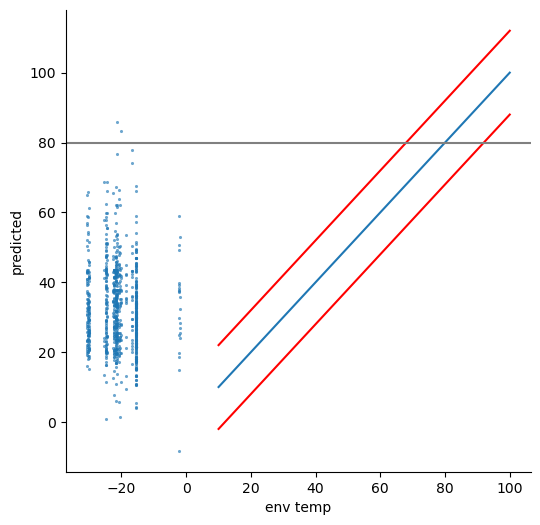

In [203]:
plotdf = plot_predictions(col_datasets, y)

# ax.set_title('Mycobacteria')

In [205]:
plotdf.to_csv('./../data/validation_datasets/Antarctic/Antarctic_predictions.tsv', sep='\t')

### Error profile assessment

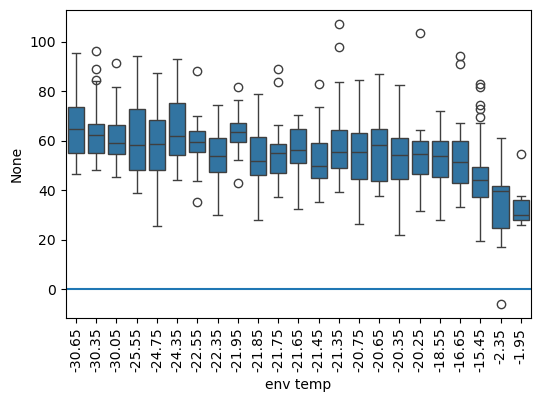

In [478]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

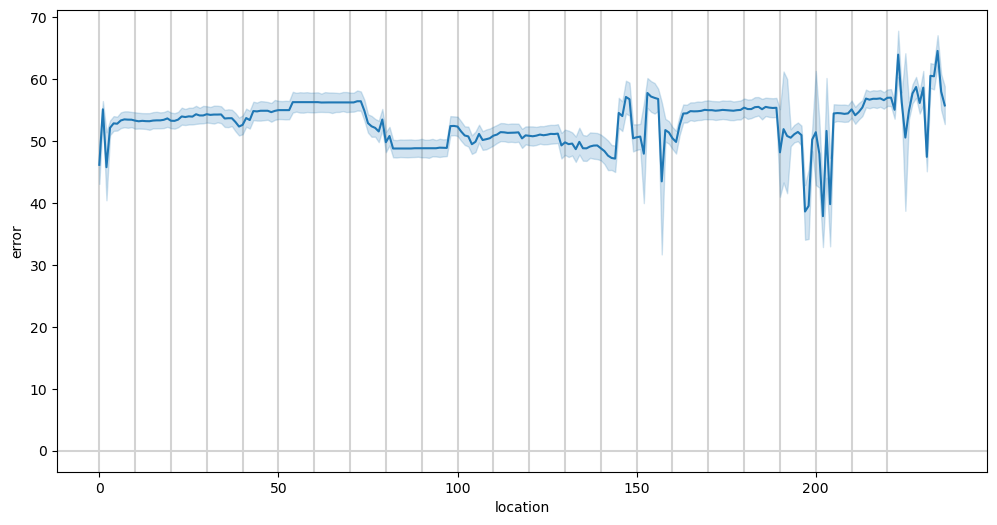

In [480]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [481]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
202,37.869550
197,38.623066
198,39.530241
204,39.807109
157,43.492985
...,...
228,58.729240
233,60.461328
232,60.539991


In [482]:
plotdf.to_csv('./../data/validation_datasets/Antarctic/Antarctic_errors.tsv', sep='\t')

# Youngblut 2020

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
cat genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [512]:
from jsonapi_client import Session
import pandas as pd
import requests

In [513]:
import json

def pp(json_obj):
    print(json.dumps(json_obj, indent=2))


In [22]:
gut_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/msystems.01045-20-st001.xlsx',
             sheet_name='Table S1C')

In [23]:
animals = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/msystems.01045-20-st001.xlsx',
             sheet_name='Table S1B')['NCBI BioProject'].unique()

## Get ENA data

In [561]:
studies = ['PRJEB11755',
'PRJEB20308',
'PRJEB22765',
'PRJEB23642',
'PRJEB29346',
'PRJEB9357']

for study in studies:
    print(study)
    study_link = f'https://www.ebi.ac.uk/metagenomics/api/v1/studies/{study}'
    print(study_link)
    study_data = requests.get(study_link).json()
    sample_link = study_data['data']['relationships']['samples']['links']['related']

    sample_data = requests.get(sample_link).json()
    for sample in sample_data['data']:
        print(sample['id'])

PRJEB11755
https://www.ebi.ac.uk/metagenomics/api/v1/studies/PRJEB11755
ERS970154
ERS970155
ERS970156
ERS970157
ERS970158
ERS970159
ERS970160
ERS970161
ERS970162
ERS970163
ERS970164
ERS970165
ERS970166
ERS970167
ERS970168
ERS970169
ERS970170
ERS970171
ERS970172
ERS970173
ERS970174
ERS970175
ERS970176
ERS970177
ERS970178
PRJEB20308
https://www.ebi.ac.uk/metagenomics/api/v1/studies/PRJEB20308


KeyError: 'data'

In [600]:
# parse manually downloaded scripts
yb2020_ena_scripts = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/*.sh')

In [641]:
df_temp_list = []
for script in yb2020_ena_scripts:
    with open(script, 'r') as handle:
        lines = handle.readlines()

    # get prj name
    prj = script.split('/')[-1].split('-')[4]
    
    # get sample names
    full_names = set([l.split('/')[-1].strip() for l in sorted(lines)])
    
    # make df of prj -> run id
    prj_df = pd.DataFrame(list(np.unique([l.split('/')[-1].strip().split('_')[0] for l in sorted(lines)])), 
                          columns=['Run_ID']).assign(project=prj)
    
    # make sure both fwd and rev are present to confirm sample is paired
    # length of set(sample_1*, sample_2*).intersection(all) should be 2
    prj_df['is_paired'] = prj_df['Run_ID'].apply(lambda x: len(set([ext for ext in [f'{x}_{i}.fastq.gz' for i in [1,2]]]).intersection(full_names)) == 2)

    df_temp_list.append(prj_df)

In [649]:
yb2020_ena = pd.concat(df_temp_list)
yb2020_ena.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/ena_srrs.csv')

In [650]:
subset = yb2020_ena.groupby(['project']).apply(lambda x: x[x.is_paired].head(100).drop('project', axis=1)).reset_index()
subset.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/subset_ena_srrs.csv')

## NCBI side

In [567]:
from Bio import Entrez
import time

In [575]:


Entrez.email = "miho1832@colorado.edu"  # Required by NCBI

def get_sra_run_accessions(bioproject_id):


    """Return list of SRR IDs for a given BioProject ID."""
    # Step 1: Search SRA database for BioProject
    handle = Entrez.esearch(db="sra", term=f"{bioproject_id}[BioProject]", retmax=100000)
    record = Entrez.read(handle)
    handle.close()
    
    sra_ids = record['IdList']
    if not sra_ids:
        print('None found')
        return []
    
    run_accessions = []
    
    # Step 2: Fetch metadata for each entry
    for sra_id in sra_ids:
        handle = Entrez.efetch(db="sra", id=sra_id, rettype="runinfo", retmode="text")
        run_info = handle.read().decode()
        handle.close()
    
        # Parse CSV-like output
        lines = run_info.strip().split("\n")
        if len(lines) > 1:
            headers = lines[0].split(",")
            idx = headers.index("Run")
            for line in lines[1:]:
                fields = line.split(",")
                run_accessions.append(fields[idx])
    
        time.sleep(0.3)  # Respect NCBI rate limits
    
    return run_accessions


In [574]:
run_accessions

['SRR3327411', 'SRR3327343']

In [578]:
[f'PRJNA3165{60 + i}' for i in range(0, 11)]

['PRJNA316560',
 'PRJNA316561',
 'PRJNA316562',
 'PRJNA316563',
 'PRJNA316564',
 'PRJNA316565',
 'PRJNA316566',
 'PRJNA316567',
 'PRJNA316568',
 'PRJNA316569',
 'PRJNA316570']

In [590]:
bioprojects = [f'PRJNA3165{60 + i}' for i in range(0, 11)] + ['PRJNA336354',
'PRJNA381379',
'PRJNA417359',
'PRJNA476660',
'PRJNA485217',
'PRJNA532626']

yb_bp2srr = []

for bprj in bioprojects:
    print(bprj)
    accessions = get_sra_run_accessions(bprj)
    yb_bp2srr.append(pd.DataFrame(accessions).rename(columns={0:'Run_ID'}).assign(BioProject=bprj))

PRJNA316560
PRJNA316561
PRJNA316562
None found
PRJNA316563
PRJNA316564
None found
PRJNA316565
PRJNA316566
PRJNA316567
PRJNA316568
None found
PRJNA316569
None found
PRJNA316570
PRJNA336354
PRJNA381379
PRJNA417359
PRJNA476660
PRJNA485217
PRJNA532626


In [592]:
yb2020_ncbi = pd.concat(yb_bp2srr)

In [594]:
yb2020_ncbi['BioProject'].value_counts()

BioProject
PRJNA417359    495
PRJNA485217    105
PRJNA532626     25
PRJNA316566     24
PRJNA316563     20
PRJNA336354     15
PRJNA381379     14
PRJNA316567      5
PRJNA476660      4
PRJNA316560      2
PRJNA316570      2
PRJNA316561      1
PRJNA316565      1
Name: count, dtype: int64

In [652]:
yb2020_ncbi.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/ncbi_srrs.csv', index=False)
subset = yb2020_ncbi.groupby(['BioProject']).apply(lambda x: x.head(100).drop('BioProject', axis=1)).reset_index()
subset.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/subset_ncbi_srrs.csv')

from md folder:
```
cut -f 4 -d, subset_ena_srrs.csv > ena_accessions.txt
grep -h -f ena_accessions.txt *.sh | sort > ena_acc_download_script.sh
cut -f 4 -d, subset_ncbi_srrs.csv > ncbi_accessions.txt
```

In [655]:
yb2020_ncbi['BioProject'].unique()

array(['PRJNA316560', 'PRJNA316561', 'PRJNA316563', 'PRJNA316565',
       'PRJNA316566', 'PRJNA316567', 'PRJNA316570', 'PRJNA336354',
       'PRJNA381379', 'PRJNA417359', 'PRJNA476660', 'PRJNA485217',
       'PRJNA532626'], dtype=object)

In [663]:

print('#!/bin/bash\nrm -r'+'*\nrm -r '.join(list(yb2020_ncbi[yb2020_ncbi.BioProject.isin(['PRJNA316561', 'PRJNA316563', 'PRJNA316565',
       'PRJNA316566', 'PRJNA316567',])].sort_values('Run_ID')['Run_ID'].values)))

#!/bin/bash
SRR3303063*
rm -r SRR3303655*
rm -r SRR3303943*
rm -r SRR3303944*
rm -r SRR3303945*
rm -r SRR3303946*
rm -r SRR3303947*
rm -r SRR3303948*
rm -r SRR3303949*
rm -r SRR3303950*
rm -r SRR3303951*
rm -r SRR3303952*
rm -r SRR3303953*
rm -r SRR3303954*
rm -r SRR3303955*
rm -r SRR3303956*
rm -r SRR3303957*
rm -r SRR3303958*
rm -r SRR3303959*
rm -r SRR3303960*
rm -r SRR3303961*
rm -r SRR3303962*
rm -r SRR3303963*
rm -r SRR3303964*
rm -r SRR3303965*
rm -r SRR3303966*
rm -r SRR3307537*
rm -r SRR3307538*
rm -r SRR3307539*
rm -r SRR3310946*
rm -r SRR3315711*
rm -r SRR3333442*
rm -r SRR3333551*
rm -r SRR3333569*
rm -r SRR3333582*
rm -r SRR3333619*
rm -r SRR3333628*
rm -r SRR3333634*
rm -r SRR3333645*
rm -r SRR3333665*
rm -r SRR3333673*
rm -r SRR3333720*
rm -r SRR3333728*
rm -r SRR3333744*
rm -r SRR3333753*
rm -r SRR3333761*
rm -r SRR3333777*
rm -r SRR3333783*
rm -r SRR3333792*
rm -r SRR3333801*
rm -r SRR3333807


## Compute predictions

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [206]:
yb_aln_df = get_aln_df('./../data/validation_datasets/Youngblut2020/keeplength_adk_nogap.afa') 

yb_aln_df = yb_aln_df[~yb_aln_df.index.isin(aln_df.index)]

yb_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
NODE_31_length_115180_cov_5.826067_21|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=162.8,-,M,-,-,I,I,M,L,G,A,...,-,D,-,-,-,-,-,-,-,-
NODE_43_length_105063_cov_15.865629_59|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.0,-,M,K,N,I,V,I,F,G,A,...,I,D,R,A,-,-,-,-,-,-
NODE_48_length_99316_cov_9.973817_31|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=167.1,-,I,-,I,F,I,-,-,A,P,...,L,R,-,-,-,S,Q,A,-,-
NODE_51_length_96540_cov_13.100275_11|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=182.4,-,M,L,Y,L,I,L,F,G,A,...,L,E,G,K,-,-,-,-,-,-
NODE_83_length_82459_cov_17.568613_58|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=205.8,-,M,-,K,I,V,F,M,G,P,...,L,G,G,N,-,K,-,-,-,-


In [207]:
data = get_esm_input(yb_aln_df)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [208]:
print(f'There are {len(data)} proteins in this dataset')

There are 648 proteins in this dataset


In [209]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 2min 40s, sys: 1min 13s, total: 3min 54s
Wall time: 25 s


In [210]:
len(labels)

648

In [211]:
yb_aln_df

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
NODE_31_length_115180_cov_5.826067_21|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=162.8,-,M,-,-,I,I,M,L,G,A,...,-,D,-,-,-,-,-,-,-,-
NODE_43_length_105063_cov_15.865629_59|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.0,-,M,K,N,I,V,I,F,G,A,...,I,D,R,A,-,-,-,-,-,-
NODE_48_length_99316_cov_9.973817_31|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=167.1,-,I,-,I,F,I,-,-,A,P,...,L,R,-,-,-,S,Q,A,-,-
NODE_51_length_96540_cov_13.100275_11|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=182.4,-,M,L,Y,L,I,L,F,G,A,...,L,E,G,K,-,-,-,-,-,-
NODE_83_length_82459_cov_17.568613_58|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=205.8,-,M,-,K,I,V,F,M,G,P,...,L,G,G,N,-,K,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NODE_1922_length_5725_cov_9.289771_8|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=182.4,M,I,-,N,L,I,L,L,G,L,...,L,S,K,D,-,-,-,-,-,-
NODE_1947_length_5641_cov_3.683136_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=191.6,-,M,-,R,L,I,F,L,G,P,...,L,E,K,-,A,S,A,-,-,-
NODE_2061_length_5384_cov_10.056859_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=178.0,-,M,-,N,L,I,L,F,G,P,...,L,A,-,-,-,-,-,-,-,-
NODE_5588_length_2478_cov_3.345027_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=160.0,-,M,V,N,I,V,L,F,G,A,...,I,D,R,K,-,-,-,-,-,-


In [213]:
col_datasets = assemble_col_dataset(yb_aln_df.reindex(index=labels), labels)

16 rows available for col 236 |--------------------|      

In [214]:
# make mapping of sequence ID to sample ID
yb_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Youngblut2020/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            yb_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [215]:
run_md = pd.merge(pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/msystems.01045-20-st001.xlsx',
             sheet_name='Table S1B'),
         pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/subset_ncbi_srrs.csv', index_col=0),
         left_on='NCBI BioProject', right_on='BioProject', how='inner')

In [216]:
body_temps = {
    "Chicken": 41.8,
    "Woodrat": 37.1,
    "Bar headed geese": 40.0,
    "Kakapo": 39.0,
    'Cow':38.6
}

In [224]:
mapper = run_md.set_index('Run_ID')['Host common name'].to_dict()
mapper['SRR3327411'] = 'Bar headed geese'
y = pd.Series(yb_record2sample).reset_index() 
y['env temp'] = y[0].map(mapper).map(body_temps)
y = y.rename(columns={'index':'protein', 0:'sample_or_genome'})

In [225]:
y

,protein,sample_or_genome,env temp
0,NODE_31_length_115180_cov_5.826067_21|scaffold...,SRR3327411,40.0
1,NODE_43_length_105063_cov_15.865629_59|scaffol...,SRR3327411,40.0
2,NODE_48_length_99316_cov_9.973817_31|scaffolds...,SRR3327411,40.0
3,NODE_51_length_96540_cov_13.100275_11|scaffold...,SRR3327411,40.0
4,NODE_83_length_82459_cov_17.568613_58|scaffold...,SRR3327411,40.0
...,...,...,...
653,NODE_1922_length_5725_cov_9.289771_8|scaffolds...,SRR6323401,41.8
654,NODE_1947_length_5641_cov_3.683136_2|scaffolds...,SRR6323401,41.8
655,NODE_2061_length_5384_cov_10.056859_2|scaffold...,SRR6323401,41.8
656,NODE_5588_length_2478_cov_3.345027_1|scaffolds...,SRR6323401,41.8


## Actual predictions

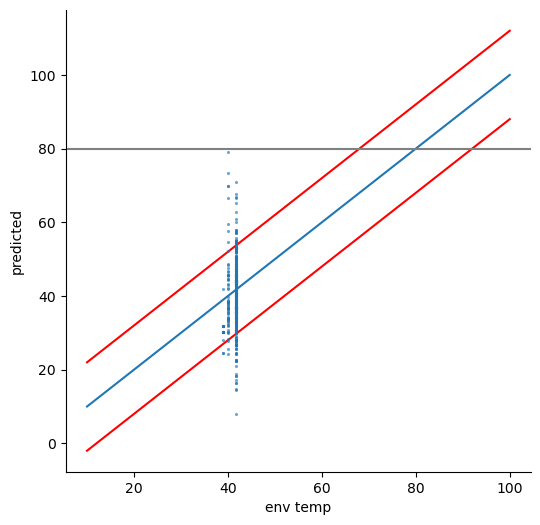

In [226]:
plotdf = plot_predictions(col_datasets, y)

In [227]:
plotdf

,predicted,protein,sample_or_genome,env temp
43,33.492519,NODE_13501_length_3146_cov_2.935296_6|scaffold...,SRR3327411,40.0
51,45.636421,NODE_35749_length_1604_cov_7.601679_2|scaffold...,SRR3327411,40.0
55,45.761887,NODE_46222_length_1354_cov_2.424172_2|scaffold...,SRR3327411,40.0
59,38.255669,NODE_77625_length_967_cov_1.948465_1|scaffolds...,SRR3327411,40.0
60,36.527611,NODE_95006_length_850_cov_1.764780_1|scaffolds...,SRR3327411,40.0
...,...,...,...,...
640,36.026604,NODE_2748_length_1995_cov_38.891753_5|scaffold...,SRR6323400,41.8
412,34.478886,NODE_35873_length_1489_cov_3.484658_1|scaffold...,SRR6323392,41.8
341,29.829702,NODE_32904_length_1788_cov_3.490479_1|scaffold...,SRR6323391,41.8
430,60.038483,NODE_145766_length_543_cov_1.928279_1|scaffold...,SRR6323392,41.8


In [228]:
plotdf.to_csv('./../data/validation_datasets/Youngblut2020/Youngblut2020_predictions.tsv', sep='\t')

# Conteville 

In [229]:
cont2024_aln_df = get_aln_df('./../data/validation_datasets/Conteville2024/keeplength_adk_nogap.afa') 

cont2024_aln_df = cont2024_aln_df[~cont2024_aln_df.index.isin(aln_df.index)]

cont2024_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,226,227,228,229,230,231,232,233,234,235
NODE_21_length_121212_cov_10.147825_103|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=173.2,-,M,K,Y,Y,I,L,F,G,P,...,D,K,F,-,-,-,-,-,-,-
NODE_46_length_95163_cov_21.825788_45|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.3,-,M,K,Y,F,I,L,F,G,P,...,N,K,F,-,-,-,-,-,-,-
NODE_119_length_59736_cov_7.347498_58|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=197.9,-,M,-,Y,I,L,L,M,G,P,...,G,-,-,-,-,C,S,K,-,-
NODE_366_length_33445_cov_10.088829_18|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=204.5,-,M,-,H,I,L,L,M,G,P,...,K,-,-,-,-,-,-,-,-,-
NODE_527_length_26880_cov_5.798882_7|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=206.2,-,M,-,K,I,I,M,L,G,A,...,E,V,-,-,-,-,-,-,-,-


In [230]:
data = get_esm_input(cont2024_aln_df)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, inval

In [231]:
print(f'There are {len(data)} proteins in this dataset')

There are 2143 proteins in this dataset


In [232]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 7min 37s, sys: 4min 54s, total: 12min 31s
Wall time: 1min 18s


In [233]:
len(labels)

2143

In [234]:
cont2024_aln_df

,0,1,2,3,4,5,6,7,8,9,...,226,227,228,229,230,231,232,233,234,235
NODE_21_length_121212_cov_10.147825_103|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=173.2,-,M,K,Y,Y,I,L,F,G,P,...,D,K,F,-,-,-,-,-,-,-
NODE_46_length_95163_cov_21.825788_45|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.3,-,M,K,Y,F,I,L,F,G,P,...,N,K,F,-,-,-,-,-,-,-
NODE_119_length_59736_cov_7.347498_58|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=197.9,-,M,-,Y,I,L,L,M,G,P,...,G,-,-,-,-,C,S,K,-,-
NODE_366_length_33445_cov_10.088829_18|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=204.5,-,M,-,H,I,L,L,M,G,P,...,K,-,-,-,-,-,-,-,-,-
NODE_527_length_26880_cov_5.798882_7|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=206.2,-,M,-,K,I,I,M,L,G,A,...,E,V,-,-,-,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NODE_94633_length_982_cov_4.804746_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=202.7,-,M,-,K,I,I,M,L,G,A,...,G,E,-,-,-,-,-,-,-,-
NODE_106505_length_901_cov_2.483452_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=121.2,-,-,-,-,-,-,-,-,-,-,...,G,E,-,-,-,-,-,-,-,-
NODE_122045_length_815_cov_1.900000_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=127.7,-,-,-,-,-,-,-,-,-,-,...,G,-,-,-,-,-,-,-,-,-
NODE_171988_length_633_cov_1.538062_1|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=121.8,-,-,-,-,-,-,-,-,-,-,...,G,D,-,-,-,-,-,-,-,-


In [235]:
col_datasets = assemble_col_dataset(cont2024_aln_df.reindex(index=labels), labels)

35 rows available for col 235 |--------------------|       

In [236]:
# make mapping of sequence ID to sample ID
cont2024_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Conteville2024/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            cont2024_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [237]:
body_temps = {
    "Chicken": 41.8,
    "Woodrat": 37.1,
    "Bar headed geese": 40.0,
    "Kakapo": 39.0,
    'Cow':38.6
}

In [243]:
mapper = dict((s, 'Cow') for s in cont2024_record2sample.values())
y = pd.Series(cont2024_record2sample).reset_index() 
y['env temp'] = y[0].map(mapper).map(body_temps)
y = y.rename(columns={'index':'protein', 0:'sample_or_genome'})

In [244]:
y

,protein,sample_or_genome,env temp
0,NODE_21_length_121212_cov_10.147825_103|scaffo...,SRR25030028,38.6
1,NODE_46_length_95163_cov_21.825788_45|scaffold...,SRR25030028,38.6
2,NODE_119_length_59736_cov_7.347498_58|scaffold...,SRR25030028,38.6
3,NODE_366_length_33445_cov_10.088829_18|scaffol...,SRR25030028,38.6
4,NODE_527_length_26880_cov_5.798882_7|scaffolds...,SRR25030028,38.6
...,...,...,...
2206,NODE_147265_length_705_cov_2.356923_1|scaffold...,SRR25030045,38.6
2207,NODE_156636_length_678_cov_2.426966_1|scaffold...,SRR25030045,38.6
2208,NODE_188608_length_604_cov_1.316940_1|scaffold...,SRR25030045,38.6
2209,NODE_195344_length_591_cov_1.296642_1|scaffold...,SRR25030045,38.6


## Actual predictions

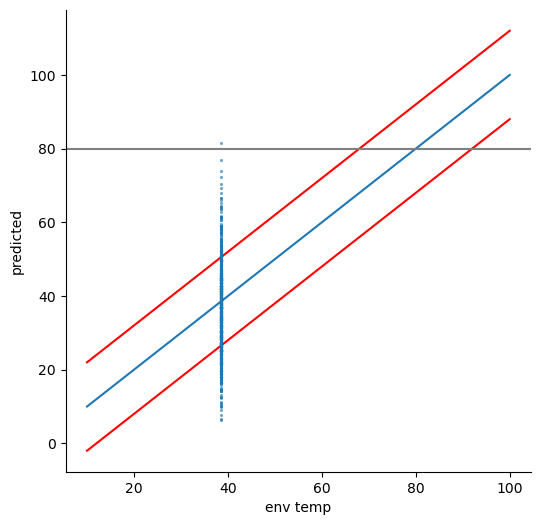

In [245]:
predictions = plot_predictions(col_datasets, y)

In [246]:
plotdf

,predicted,protein,sample_or_genome,env temp
43,33.492519,NODE_13501_length_3146_cov_2.935296_6|scaffold...,SRR3327411,40.0
51,45.636421,NODE_35749_length_1604_cov_7.601679_2|scaffold...,SRR3327411,40.0
55,45.761887,NODE_46222_length_1354_cov_2.424172_2|scaffold...,SRR3327411,40.0
59,38.255669,NODE_77625_length_967_cov_1.948465_1|scaffolds...,SRR3327411,40.0
60,36.527611,NODE_95006_length_850_cov_1.764780_1|scaffolds...,SRR3327411,40.0
...,...,...,...,...
640,36.026604,NODE_2748_length_1995_cov_38.891753_5|scaffold...,SRR6323400,41.8
412,34.478886,NODE_35873_length_1489_cov_3.484658_1|scaffold...,SRR6323392,41.8
341,29.829702,NODE_32904_length_1788_cov_3.490479_1|scaffold...,SRR6323391,41.8
430,60.038483,NODE_145766_length_543_cov_1.928279_1|scaffold...,SRR6323392,41.8


In [247]:
plotdf.to_csv('./../data/validation_datasets/Conteville2024/Conteville2024_predictions.tsv', sep='\t')

# Summary figures

In [248]:
files = glob.glob('./../data/validation_datasets/*/*_predictions.tsv')

In [253]:
dataset = pd.concat([pd.read_csv(f, sep='\t').assign(dataset=f.split('/')[-1].split('_pred')[0]) for f in files])

dataset2label = {'Antarctic':'Antarctic soil', 
                 'Australia':'Australian soil', 
                 'Coleman2024':'Hot spring genome assemblies', 
                 'RoyoLlonch2021':'Arctic ocean (TARA)', 
                 'Shah2024':'European freshwater lakes',
                'Youngblut2020':'Avian microbiomes',
                'Conteville2024':'Bovine microbiomes'}

dataset['dataset_label'] = dataset['dataset'].map(dataset2label)

In [122]:
plotdf = dataset.groupby(['dataset', 'env temp']).agg(predicted_mean=('predicted','mean'),
                                              predicted_std=('predicted','std')).reset_index()

In [258]:
dataset['dataset_label'].unique()

array(['Antarctic soil', 'Arctic ocean (TARA)', 'Australian soil',
       'European freshwater lakes', 'Hot spring genome assemblies',
       'Bovine microbiomes', 'Avian microbiomes'], dtype=object)

In [270]:
dataset = dataset.reset_index(drop=True)

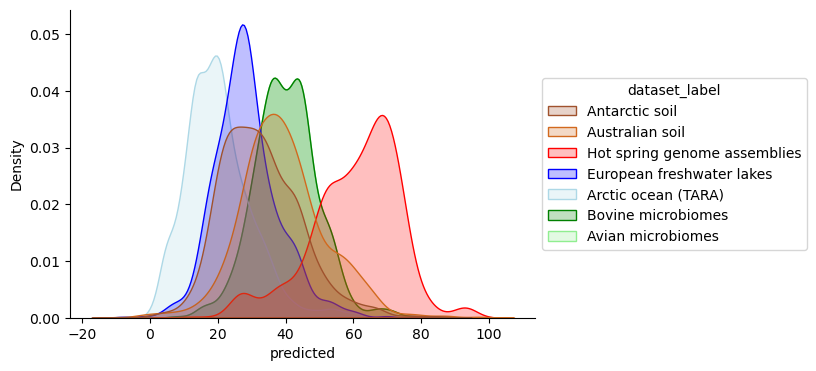

In [323]:
fig, ax = plt.subplots(figsize=(6,4))
g = sns.kdeplot(data=dataset, x='predicted', hue='dataset_label', #hist=False,
             ax=ax, common_norm=False, 
                palette = ['sienna', 'chocolate', 'red',  'blue', 'lightblue', 'Green', 'lightgreen'],
                hue_order=[ 
                           'Antarctic soil',   'Australian soil','Hot spring genome assemblies',
       'European freshwater lakes', 'Arctic ocean (TARA)', 'Bovine microbiomes','Avian microbiomes',],
                # kde=True, 
            #stat='density',
            fill=True)
# ax.get_legend().remove()
lgd = ax.get_legend()
lgd._loc = 6
lgd.set_bbox_to_anchor((1, 0.5))
sns.despine()

In [333]:
dataset.groupby(['dataset_label', 'sample_or_genome'])[['predicted', 'env temp']].mean().reset_index()

,dataset_label,sample_or_genome,predicted,env temp
0,Antarctic soil,BPS5,39.777378,-24.35
1,Antarctic soil,BS610,35.201179,-30.65
2,Antarctic soil,BS620,33.311092,NaN
3,Antarctic soil,CBCMBjA1,33.191876,-30.35
4,Antarctic soil,CR0819,29.165532,-15.45
...,...,...,...,...
409,Hot spring genome assemblies,GCA_032249775.1,36.896300,84.00
410,Hot spring genome assemblies,GCA_032249795.1,61.835224,84.00
411,Hot spring genome assemblies,GCA_046533595.1,51.202305,72.60
412,Hot spring genome assemblies,GCA_046534135.1,28.615220,71.40


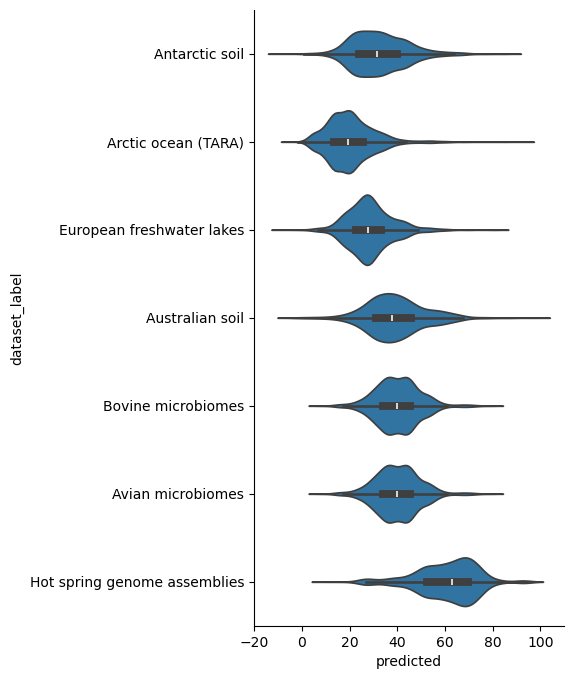

In [336]:
fig, ax = plt.subplots(figsize=(4, 8))
sns.violinplot(data=dataset, #.groupby(['dataset_label', 'sample_or_genome'])[['predicted', 'env temp']].mean().reset_index(),
               x='predicted', y='dataset_label', order=['Antarctic soil', 'Arctic ocean (TARA)', 
                                                          'European freshwater lakes', 'Australian soil', 
                                                          'Bovine microbiomes', 'Avian microbiomes', 'Hot spring genome assemblies'])

# sns.violinplot(data=dataset,
#                x='env temp', y='dataset_label', order=['Antarctic soil', 'Arctic ocean (TARA)', 
#                                                           'European freshwater lakes', 'Australian soil', 
#                                                           'Bovine microbiomes', 'Avian microbiomes', 'Hot spring genome assemblies'])

sns.despine()

In [ ]:
sns.scatterplot(data=dataset, x='env temp', y='predicted')

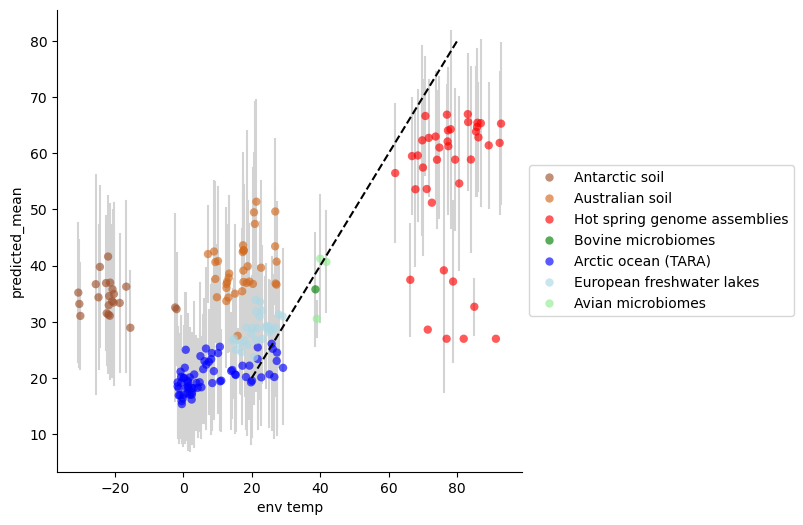

In [131]:
fig, ax = plt.subplots(figsize=(6,6))

palette = ['sienna', 'chocolate', 'red', 'Green',  'blue', 'lightblue', 'lightgreen']

sns.scatterplot(data=plotdf,
                x='env temp',
                y='predicted_mean',
                linewidth=0, alpha=0.65, hue='hue', palette=palette, zorder=2)

# ax = lineplot(plotdf, ax, 'hue', palette)

for index, row in plotdf.iterrows():
    # print('plotting')
    plt.plot((row['env temp'], row['env temp']), 
             (row['predicted_mean']+row['predicted_std'], 
              row['predicted_mean']-row['predicted_std']),
             color='lightgray',
             zorder=0
            ) 


plt.plot((20, 80), (20, 80), color='k', linestyle='--')

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()


In [133]:
files = glob.glob('./../data/validation_datasets/*/*_error*.tsv')

In [134]:
dataset = pd.concat([pd.read_csv(f, sep='\t').assign(dataset=f.split('/')[-1].split('_errors')[0]) for f in files])

/tmp/ipykernel_1735367/2164351726.py:2: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.lineplot(data=dataset, x='location', y='error', hue='dataset', palette=palette)


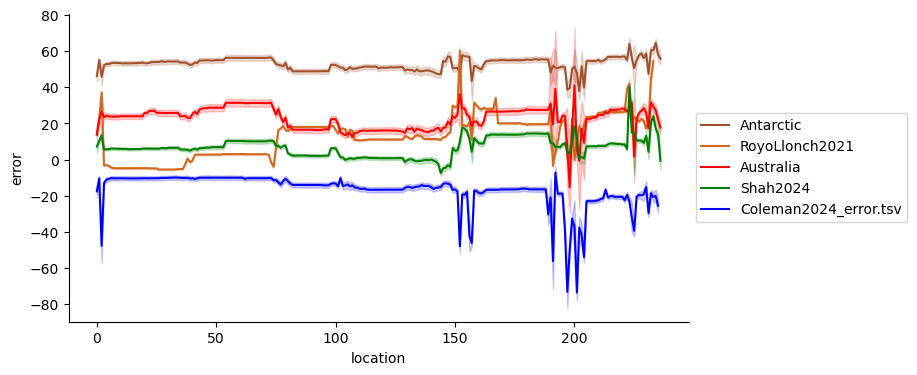

In [135]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=dataset, x='location', y='error', hue='dataset', palette=palette)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()